# Module 4 & 5 Master Notebook — Mathematics & Statistics for Machine Learning
### Days 17 to 29 | AI & ML Mastery Program

---

## What This Notebook Covers

In Days 1–16, you learned:
- Python fundamentals (variables, loops, functions, OOP)
- NumPy (arrays, vectorization, broadcasting)
- Pandas (DataFrames, groupby, feature engineering)
- Matplotlib & Seaborn (visualization)

In Days 17–29, your instructor explained the **mathematical backbone** of ML on a whiteboard:
- **Module 4 (Days 17–21):** Calculus, Differentiation, Gradients, Integration, Linear Algebra
- **Module 5 (Days 22–29):** Probability, Distributions, Statistics, Hypothesis Testing

**This notebook connects those dots.** Every concept you saw on a whiteboard is now coded in Python, visualized, and connected to how it is actually used inside Machine Learning algorithms.

---

## Roadmap

| Section | Topics | Days |
|---------|---------|------|
| 1 | Calculus Foundations – Derivatives & Limits | Day 17 |
| 2 | Differentiation Rules & Gradient Descent | Day 18 |
| 3 | Multivariable Calculus & Gradients | Day 19 |
| 4 | Integration, Vectors & Vector Operations | Day 20 |
| 5 | Linear Algebra – Matrices, Eigenvalues & SVD | Day 21 |
| 6 | Probability Foundations & Counting | Day 22 |
| 7 | Conditional Probability & Bayes Theorem | Day 23 |
| 8 | Random Variables & Discrete Distributions | Day 24 |
| 9 | Continuous Distributions & Normal Distribution | Day 25 |
| 10 | Statistical Measures & Correlation | Day 26 |
| 11 | Hypothesis Testing & t-Tests | Day 27 |
| 12 | Data Transformations & Skewness | Day 28 |
| 13 | Mini Project: Health Insurance Statistical Analysis | Day 29 |

---

**Author:** AI & ML Mastery Program | **Mahipal Singh** | **Libraries used:** NumPy, SciPy, Pandas, Matplotlib, Seaborn, SymPy

In [41]:
# ============================================================
# CELL 1 — Import all libraries needed for this entire notebook
# Run this cell FIRST before running any other cell
# ============================================================

import numpy as np                         # Array math, linear algebra
import pandas as pd                        # DataFrames and data manipulation
import matplotlib.pyplot as plt            # Plotting and visualization
import matplotlib.gridspec as gridspec     # Advanced subplot layouts
import seaborn as sns                      # Statistical plots on top of matplotlib
import sympy as sp                         # Symbolic mathematics (exact derivatives, integrals)
from scipy import stats                    # Statistical distributions and tests
from scipy import integrate                # Numerical integration
from scipy import linalg                   # Linear algebra (scipy version)
from scipy.stats import boxcox             # Box-Cox transformation
import warnings                            # Suppress harmless warnings
warnings.filterwarnings('ignore')          # Keep output clean

# Set consistent plot style for all charts in this notebook
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (10, 5)  # Default figure size
plt.rcParams['axes.spines.top'] = False   # Remove top spine for cleaner look
plt.rcParams['axes.spines.right'] = False # Remove right spine

print(" All libraries loaded successfully!")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")
import scipy; print(f"   SciPy  : {scipy.__version__}")
print(f"   SymPy  : {sp.__version__}")

 All libraries loaded successfully!
   NumPy  : 1.26.4
   Pandas : 2.1.4
   SciPy  : 1.11.4
   SymPy  : 1.13.3


---
# SECTION 1 — Calculus Foundations: Derivatives & Limits
### Day 17 | Module 4

**What your instructor showed on the whiteboard:**
- A function f(x) and its graph
- The limit definition of a derivative: `lim(h→0) [f(x+h) - f(x)] / h`
- Derivatives of common functions: `xⁿ`, `eˣ`, `ln(x)`

**Why it matters in ML:**
- Every ML training algorithm uses derivatives to find the direction of error reduction
- The **loss function** (e.g., Mean Squared Error) is minimized using its derivative
- Without derivatives → no gradient descent → no learning

In [42]:
# ============================================================
# CELL 2 — Symbolic Derivatives using SymPy
# SymPy computes EXACT mathematical derivatives, not numerical approximations
# ============================================================

# Define a symbolic variable 'x' — this is not a Python number, it's a math symbol
x = sp.Symbol('x')

# Define several functions we want to differentiate
f1 = x**3 - 3*x**2 + 2*x - 1    # A cubic polynomial
f2 = sp.exp(x)                    # The exponential function e^x
f3 = sp.log(x)                    # Natural logarithm ln(x)
f4 = sp.sin(x)                    # Sine function

print("=" * 50)
print("SYMBOLIC DERIVATIVES (exact math)")
print("=" * 50)

# sp.diff() computes the derivative with respect to x
print(f"\nf(x)  = {f1}")
print(f"f'(x) = {sp.diff(f1, x)}")   # d/dx(x³ - 3x² + 2x - 1) = 3x² - 6x + 2

print(f"\nf(x)  = e^x")
print(f"f'(x) = {sp.diff(f2, x)}")   # d/dx(e^x) = e^x  ← unique: derivative equals itself!

print(f"\nf(x)  = ln(x)")
print(f"f'(x) = {sp.diff(f3, x)}")   # d/dx(ln(x)) = 1/x

print(f"\nf(x)  = sin(x)")
print(f"f'(x) = {sp.diff(f4, x)}")   # d/dx(sin(x)) = cos(x)

print("\n ML Connection: Cross-entropy loss uses log(). Sigmoid uses e^x.")
print("   Knowing their derivatives lets us compute gradients during training.")

SYMBOLIC DERIVATIVES (exact math)

f(x)  = x**3 - 3*x**2 + 2*x - 1
f'(x) = 3*x**2 - 6*x + 2

f(x)  = e^x
f'(x) = exp(x)

f(x)  = ln(x)
f'(x) = 1/x

f(x)  = sin(x)
f'(x) = cos(x)

 ML Connection: Cross-entropy loss uses log(). Sigmoid uses e^x.
   Knowing their derivatives lets us compute gradients during training.


In [43]:
def numerical_derivative(f, x_val, h=1e-5):
    """
    Central difference approximation of derivative.
    Formula: [f(x+h) - f(x-h)] / (2h)
    """
    return (f(x_val + h) - f(x_val - h)) / (2 * h)

# f(x) = x^3 - 3x^2 + 2x - 1
def my_function(x):
    return x**3 - 3*x**2 + 2*x - 1

# f'(x) = 3x^2 - 6x + 2
def exact_derivative(x):
    return 3*x**2 - 6*x + 2

test_points = [0, 1, 2, 3, -1]

print(f"{'x':>5} | {'Numerical f(x)':>18} | {'Exact f(x)':>15} | {'Error':>12}")
print("-" * 60)

for xv in test_points:
    num = numerical_derivative(my_function, xv)
    exact = exact_derivative(xv)
    error = abs(num - exact)

    print(f"{xv:>5} | {num:>18.10f} | {exact:>15.10f} | {error:>12.2e}")

print("\n Numerical derivative is very close to exact.")
print("This is how ML frameworks perform gradient checking.")

    x |     Numerical f(x) |      Exact f(x) |        Error
------------------------------------------------------------
    0 |       2.0000000001 |    2.0000000000 |     1.02e-10
    1 |      -0.9999999999 |   -1.0000000000 |     1.04e-10
    2 |       2.0000000001 |    2.0000000000 |     1.46e-10
    3 |      11.0000000002 |   11.0000000000 |     2.05e-10
   -1 |      11.0000000001 |   11.0000000000 |     1.16e-10

 Numerical derivative is very close to exact.
This is how ML frameworks perform gradient checking.


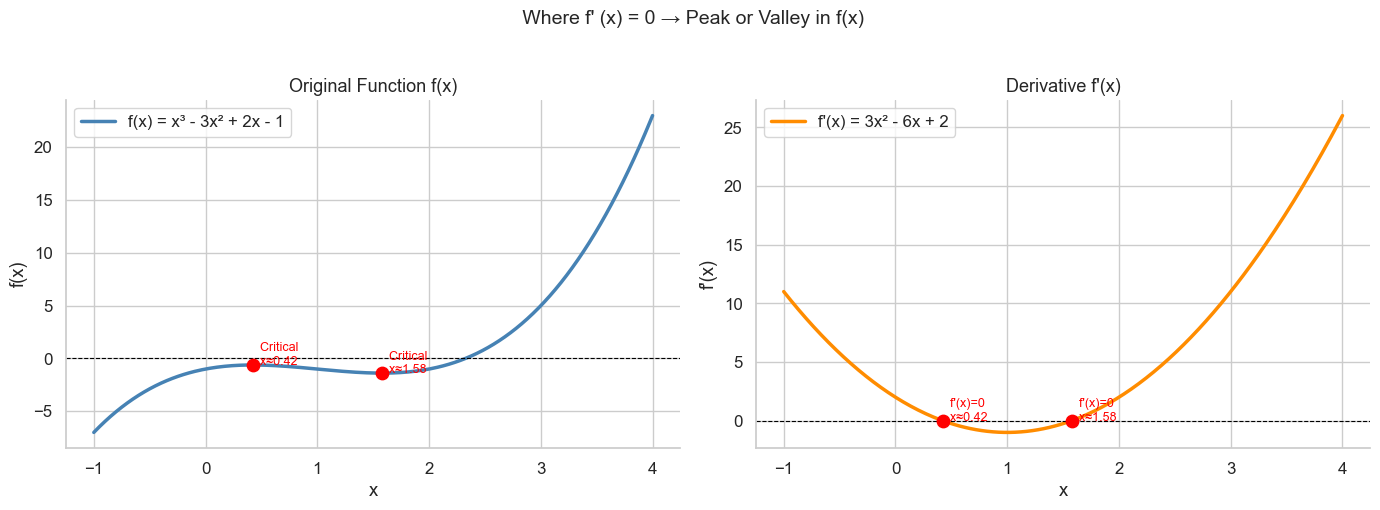


 ML Connection: During training, we search for the point where loss'(weights) = 0
   That is the minimum of the loss function — the best set of model weights!


In [44]:
# ============================================================
# CELL 4 — Plot a function and its derivative together
# Visual proof: where f'(x) = 0 is where f(x) has peaks/valleys
# ============================================================

x_vals = np.linspace(-1, 4, 300)          # 300 evenly spaced x values from -1 to 4
y_vals = x_vals**3 - 3*x_vals**2 + 2*x_vals - 1   # f(x) values
dy_vals = 3*x_vals**2 - 6*x_vals + 2              # f'(x) values

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))  # Side-by-side plots

# Left plot: the original function f(x)
ax1.plot(x_vals, y_vals, color='steelblue', lw=2.5, label='f(x) = x³ - 3x² + 2x - 1')
ax1.axhline(0, color='black', lw=0.8, linestyle='--')   # x-axis reference line
# Mark critical points (where f'(x) = 0 → local max/min)
# Solving 3x^2 - 6x + 2 = 0 gives x ≈ 0.423 and x ≈ 1.577
for cx in [0.4226, 1.5774]:
    cy = cx**3 - 3*cx**2 + 2*cx - 1
    ax1.scatter([cx], [cy], color='red', zorder=5, s=80)
    ax1.annotate(f'  Critical\n  x≈{cx:.2f}', xy=(cx, cy), fontsize=9, color='red')
ax1.set_title('Original Function f(x)', fontsize=13)
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.legend()

# Right plot: derivative f'(x)
ax2.plot(x_vals, dy_vals, color='darkorange', lw=2.5, label="f'(x) = 3x² - 6x + 2")
ax2.axhline(0, color='black', lw=0.8, linestyle='--')   # f'(x)=0 line
# Mark where derivative crosses zero (these are the critical points)
for cx in [0.4226, 1.5774]:
    ax2.scatter([cx], [0], color='red', zorder=5, s=80)
    ax2.annotate(f"  f'(x)=0\n  x≈{cx:.2f}", xy=(cx, 0), fontsize=9, color='red')
ax2.set_title("Derivative f'(x)", fontsize=13)
ax2.set_xlabel('x')
ax2.set_ylabel("f'(x)")
ax2.legend()

plt.suptitle(' Where f\' (x) = 0 → Peak or Valley in f(x)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n ML Connection: During training, we search for the point where loss'(weights) = 0")
print("   That is the minimum of the loss function — the best set of model weights!")

---
# SECTION 2 — Differentiation Rules & Gradient Descent
### Day 18 | Module 4

**What your instructor showed on the whiteboard:**
- Chain rule, product rule, quotient rule
- Local vs global minima in a loss landscape
- Gradient descent update rule: `x ← x - α · f'(x)`

**Why it matters in ML:**
- The **chain rule** is the mathematical engine behind **backpropagation** in neural networks
- **Gradient descent** is used to train **every** ML model (Linear Regression, Logistic Regression, Neural Nets)
- Learning rate α controls how big each update step is

In [45]:
# ============================================================
# CELL 5 — Chain Rule: The Engine of Backpropagation
# Chain rule: d/dx[f(g(x))] = f'(g(x)) · g'(x)
# ============================================================

x = sp.Symbol('x')   # Symbolic x for exact computation

print("CHAIN RULE EXAMPLES — d/dx[f(g(x))] = f'(g(x)) · g'(x)")
print("=" * 60)

# Example 1: Outer function is square, inner is linear → (2x+1)^2
expr1 = (2*x + 1)**2
print(f"\nExample 1: (2x + 1)²")
print(f"  d/dx = {sp.diff(expr1, x)}")     # 2*(2x+1)*2 = 4*(2x+1)
print(f"  Simplified = {sp.simplify(sp.diff(expr1, x))}")

# Example 2: Log of a linear function → ln(3x² + 1)
expr2 = sp.log(3*x**2 + 1)
print(f"\nExample 2: ln(3x² + 1)")
print(f"  d/dx = {sp.diff(expr2, x)}")     # 6x / (3x^2 + 1)

# Example 3: Sigmoid function σ(x) = 1 / (1 + e^{-x})
# CRITICAL: This is the output layer of binary classifiers (Logistic Regression, Neural Nets)
sigmoid = 1 / (1 + sp.exp(-x))
sigmoid_deriv = sp.diff(sigmoid, x)
simplified_deriv = sp.simplify(sigmoid_deriv)
print(f"\nExample 3: Sigmoid σ(x) = 1/(1+e^(-x))")
print(f"  d/dx = {simplified_deriv}")
print(f"   This simplifies to: σ(x) · (1 - σ(x))")
print(f"  → This exact formula is used in Logistic Regression gradient descent!")

# Example 4: Chain rule in neural nets
# If Loss = MSE(prediction) and prediction = sigmoid(wx + b)
# then d(Loss)/d(w) = d(Loss)/d(pred) · d(pred)/d(wx+b) · d(wx+b)/d(w)
print(f"\n In a Neural Network:")
print(f"   dL/dw = (dL/d_output) × (d_output/d_activation) × (d_activation/dw)")
print(f"   This is 3 chain rule steps applied together — that's backpropagation!")

CHAIN RULE EXAMPLES — d/dx[f(g(x))] = f'(g(x)) · g'(x)

Example 1: (2x + 1)²
  d/dx = 8*x + 4
  Simplified = 8*x + 4

Example 2: ln(3x² + 1)
  d/dx = 6*x/(3*x**2 + 1)

Example 3: Sigmoid σ(x) = 1/(1+e^(-x))
  d/dx = 1/(4*cosh(x/2)**2)
   This simplifies to: σ(x) · (1 - σ(x))
  → This exact formula is used in Logistic Regression gradient descent!

 In a Neural Network:
   dL/dw = (dL/d_output) × (d_output/d_activation) × (d_activation/dw)
   This is 3 chain rule steps applied together — that's backpropagation!


In [46]:
# ============================================================
# CELL 6 — Gradient Descent from Scratch (1D)
# We minimize a simple loss function: L(w) = (w - 3)²
# The minimum is obviously at w=3, gradient descent should find it
# ============================================================

def loss(w):
    """Simple quadratic loss: L(w) = (w - 3)²
    The true minimum is at w=3 where loss=0"""
    return (w - 3) ** 2    # Squared distance from 3

def loss_gradient(w):
    """Derivative of L(w) = (w-3)²
    dL/dw = 2(w - 3)"""
    return 2 * (w - 3)     # Slope of the loss at current w

# Gradient Descent Algorithm
w = 9.0          # Start far from the minimum (w=3)
alpha = 0.1      # Learning rate: how big each step is
n_steps = 30     # Number of gradient descent steps

history_w = [w]        # Track w value at each step
history_loss = [loss(w)]  # Track loss at each step

print(f"{'Step':>5} | {'w':>10} | {'Loss':>12} | {'Gradient':>12}")
print("-" * 48)
print(f"{0:>5} | {w:>10.4f} | {loss(w):>12.4f} | {loss_gradient(w):>12.4f}")

for step in range(1, n_steps + 1):
    grad = loss_gradient(w)   # Compute gradient at current w
    w = w - alpha * grad      # Update rule: move opposite to gradient
    history_w.append(w)
    history_loss.append(loss(w))
    if step <= 10 or step == n_steps:   # Print first 10 + last step
        print(f"{step:>5} | {w:>10.4f} | {loss(w):>12.6f} | {grad:>12.4f}")

print(f"\n Final w = {w:.6f}  (true minimum is w = 3.0)")
print(f"   Final loss = {loss(w):.2e}  (very close to 0!)")
print(f"\n This is EXACTLY how Linear Regression and Neural Networks are trained!")

 Step |          w |         Loss |     Gradient
------------------------------------------------
    0 |     9.0000 |      36.0000 |      12.0000
    1 |     7.8000 |    23.040000 |      12.0000
    2 |     6.8400 |    14.745600 |       9.6000
    3 |     6.0720 |     9.437184 |       7.6800
    4 |     5.4576 |     6.039798 |       6.1440
    5 |     4.9661 |     3.865471 |       4.9152
    6 |     4.5729 |     2.473901 |       3.9322
    7 |     4.2583 |     1.583297 |       3.1457
    8 |     4.0066 |     1.013310 |       2.5166
    9 |     3.8053 |     0.648518 |       2.0133
   10 |     3.6442 |     0.415052 |       1.6106
   30 |     3.0074 |     0.000055 |       0.0186

 Final w = 3.007428  (true minimum is w = 3.0)
   Final loss = 5.52e-05  (very close to 0!)

 This is EXACTLY how Linear Regression and Neural Networks are trained!


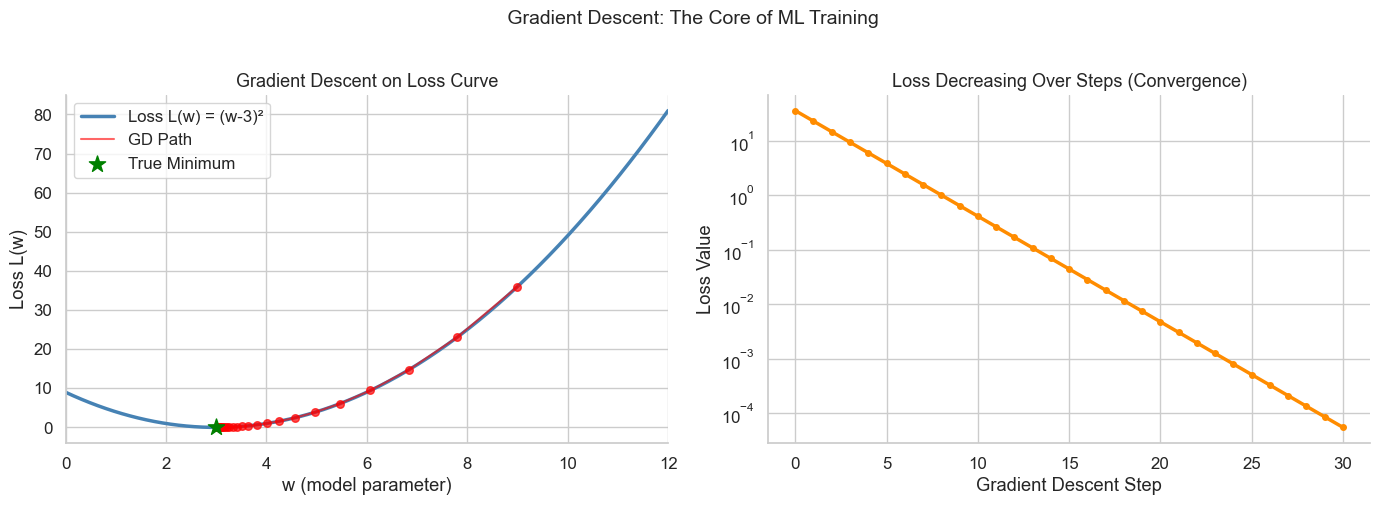

 Every time you call model.fit() in sklearn or model.train() in PyTorch,
   the library is running this exact process — thousands of times — on millions of parameters.


In [47]:
# ============================================================
# CELL 7 — Visualize Gradient Descent Steps
# Shows the ball rolling down the loss curve, step by step
# ============================================================

w_range = np.linspace(0, 12, 300)            # Range for plotting the loss curve
loss_curve = (w_range - 3) ** 2              # Loss at every w value

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: The loss curve with gradient descent path
ax1.plot(w_range, loss_curve, color='steelblue', lw=2.5, label='Loss L(w) = (w-3)²')
# Plot the gradient descent trajectory
gd_losses = [loss(wv) for wv in history_w]  # Loss at each step's w
ax1.scatter(history_w, gd_losses, color='red', s=30, zorder=5, alpha=0.7)
ax1.plot(history_w, gd_losses, color='red', lw=1.5, alpha=0.6, label='GD Path')
ax1.scatter([3], [0], color='green', s=150, zorder=6, marker='*', label='True Minimum')
ax1.set_title('Gradient Descent on Loss Curve', fontsize=13)
ax1.set_xlabel('w (model parameter)')
ax1.set_ylabel('Loss L(w)')
ax1.legend()
ax1.set_xlim(0, 12)

# Right plot: Loss decreasing over steps (convergence plot)
ax2.plot(range(n_steps + 1), history_loss, color='darkorange', lw=2.5, marker='o', markersize=4)
ax2.set_title('Loss Decreasing Over Steps (Convergence)', fontsize=13)
ax2.set_xlabel('Gradient Descent Step')
ax2.set_ylabel('Loss Value')
ax2.set_yscale('log')    # Log scale to see convergence clearly

plt.suptitle(' Gradient Descent: The Core of ML Training', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(" Every time you call model.fit() in sklearn or model.train() in PyTorch,")
print("   the library is running this exact process — thousands of times — on millions of parameters.")

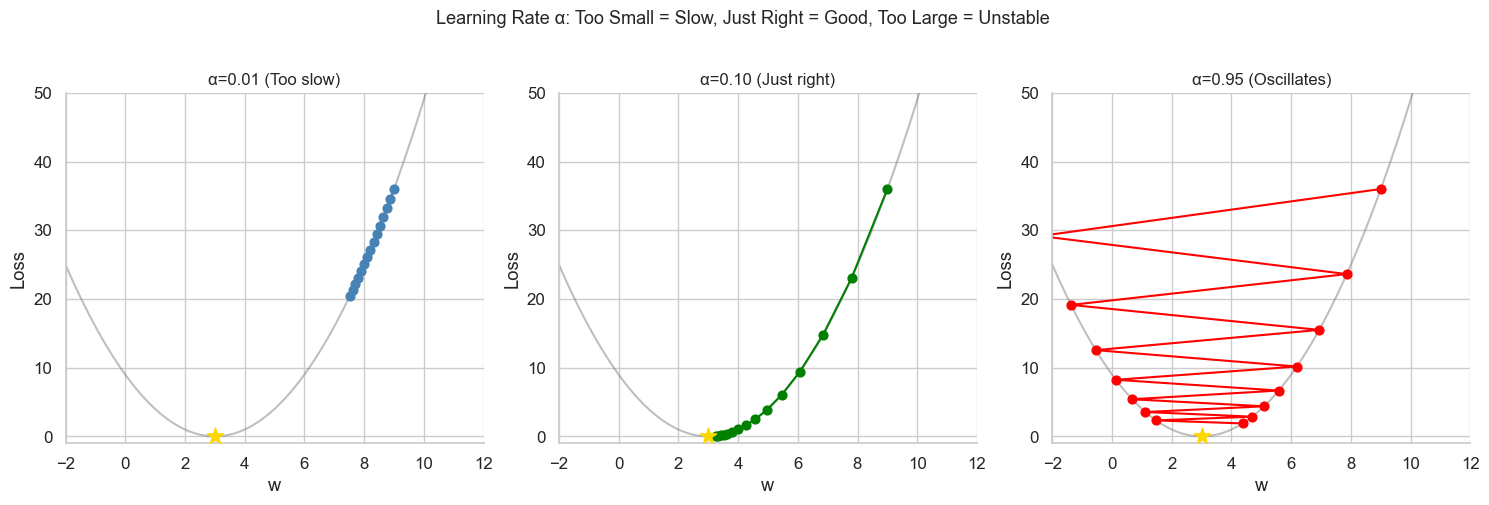

In [48]:
# ============================================================
# CELL 8 — Effect of Learning Rate on Gradient Descent
# Too large: oscillates or diverges. Too small: converges slowly.
# ============================================================

def run_gd(start_w, alpha, steps=40):
    """Run gradient descent and return w and loss history."""
    w = start_w
    wh, lh = [w], [loss(w)]
    for _ in range(steps):
        w = w - alpha * loss_gradient(w)  # Standard gradient descent step
        wh.append(w)
        lh.append(loss(w))
    return wh, lh

# Compare three different learning rates
alphas = [0.01, 0.1, 0.95]              # Small, good, too large
labels = ['α=0.01 (Too slow)', 'α=0.10 (Just right)', 'α=0.95 (Oscillates)']
colors = ['steelblue', 'green', 'red']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
w_range = np.linspace(-2, 14, 300)

for i, (alpha, label, color) in enumerate(zip(alphas, labels, colors)):
    wh, lh = run_gd(9.0, alpha)    # Start at w=9, run with this learning rate
    axes[i].plot(w_range, (w_range - 3)**2, color='gray', lw=1.5, alpha=0.5)
    # Show first 15 steps of the path
    axes[i].scatter(wh[:15], [(w-3)**2 for w in wh[:15]], color=color, s=40, zorder=5)
    axes[i].plot(wh[:15], [(w-3)**2 for w in wh[:15]], color=color, lw=1.5)
    axes[i].scatter([3], [0], color='gold', s=150, zorder=6, marker='*')  # True min
    axes[i].set_title(label, fontsize=12)
    axes[i].set_xlabel('w')
    axes[i].set_ylabel('Loss')
    axes[i].set_xlim(-2, 12)
    axes[i].set_ylim(-1, 50)

plt.suptitle(' Learning Rate α: Too Small = Slow, Just Right = Good, Too Large = Unstable',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
# SECTION 3 — Multivariable Calculus & Gradients
### Day 19 | Module 4

**What your instructor showed on the whiteboard:**
- Partial derivatives ∂f/∂x and ∂f/∂y
- Gradient vector ∇f pointing uphill
- Gradient descent in 2D: update both parameters simultaneously

**Why it matters in ML:**
- Every ML model has **multiple parameters** (not just one w)
- Linear Regression with n features has n+1 parameters → we need **partial derivatives** for each
- Neural networks can have **billions** of parameters — all updated simultaneously each training step

In [49]:
# ============================================================
# CELL 9 — Partial Derivatives using SymPy
# Partial derivative: differentiate w.r.t. one variable, treat others as constants
# ============================================================

x, y = sp.symbols('x y')    # Two symbolic variables

# MSE loss for Linear Regression with 2 parameters w0 (bias) and w1 (slope)
# If we have a single data point (x=2, y_true=5) and prediction = w1*x + w0
# Then MSE loss = (y_true - prediction)^2 = (5 - w1*2 - w0)^2
w0, w1, x_data, y_true = sp.symbols('w0 w1 x_data y_true')
prediction = w1 * x_data + w0                        # Linear model prediction
mse_loss = (y_true - prediction) ** 2               # MSE = squared error

print("MSE Loss (single data point):")
print(f"  L(w0, w1) = (y_true - w1·x - w0)²")
print(f"            = {sp.expand(mse_loss)}")

# Partial derivative with respect to w0 (the bias parameter)
dL_dw0 = sp.diff(mse_loss, w0)
print(f"\n∂L/∂w0 (bias gradient)  = {dL_dw0}")
print(f"  Simplified            = {sp.simplify(dL_dw0)}")

# Partial derivative with respect to w1 (the slope/weight)
dL_dw1 = sp.diff(mse_loss, w1)
print(f"\n∂L/∂w1 (weight gradient) = {dL_dw1}")
print(f"  Simplified             = {sp.simplify(dL_dw1)}")

print(f"\n Both gradients combined form the GRADIENT VECTOR: ∇L = [∂L/∂w0, ∂L/∂w1]")
print(f"   Update rule: w0 ← w0 - α·(∂L/∂w0)")
print(f"                w1 ← w1 - α·(∂L/∂w1)")
print(f"   This happens simultaneously for all parameters in every training step!")

MSE Loss (single data point):
  L(w0, w1) = (y_true - w1·x - w0)²
            = w0**2 + 2*w0*w1*x_data - 2*w0*y_true + w1**2*x_data**2 - 2*w1*x_data*y_true + y_true**2

∂L/∂w0 (bias gradient)  = 2*w0 + 2*w1*x_data - 2*y_true
  Simplified            = 2*w0 + 2*w1*x_data - 2*y_true

∂L/∂w1 (weight gradient) = -2*x_data*(-w0 - w1*x_data + y_true)
  Simplified             = 2*x_data*(w0 + w1*x_data - y_true)

 Both gradients combined form the GRADIENT VECTOR: ∇L = [∂L/∂w0, ∂L/∂w1]
   Update rule: w0 ← w0 - α·(∂L/∂w0)
                w1 ← w1 - α·(∂L/∂w1)
   This happens simultaneously for all parameters in every training step!


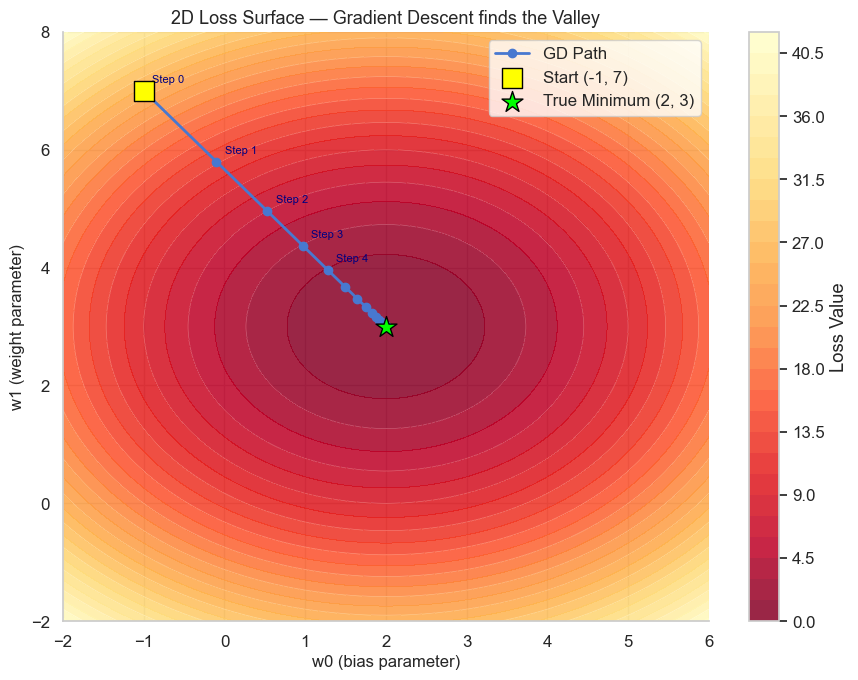


 In real ML: This 2D surface becomes a surface in MILLIONS of dimensions.
   GPT-4 has ~1.8 trillion parameters — gradient descent updates all of them each step!


In [50]:
# ============================================================
# CELL 10 — 2D Loss Surface and Gradient Descent Path
# Visualize how gradient descent navigates a 2D loss landscape
# ============================================================

# Create a bowl-shaped 2D loss surface
# L(w0, w1) = (w0 - 2)^2 + (w1 - 3)^2  → minimum at (2, 3)
w0_range = np.linspace(-2, 6, 200)     # w0 axis
w1_range = np.linspace(-2, 8, 200)     # w1 axis
W0, W1 = np.meshgrid(w0_range, w1_range)   # Create 2D grid for surface plot
Loss_surface = (W0 - 2)**2 + (W1 - 3)**2   # Loss value at every (w0, w1)

# Run 2D gradient descent starting from (-1, 7)
w0_curr, w1_curr = -1.0, 7.0   # Starting point (far from minimum)
alpha_2d = 0.15                 # Learning rate
path_w0, path_w1 = [w0_curr], [w1_curr]

for _ in range(25):                          # 25 gradient descent steps
    grad_w0 = 2 * (w0_curr - 2)             # ∂L/∂w0 = 2(w0 - 2)
    grad_w1 = 2 * (w1_curr - 3)             # ∂L/∂w1 = 2(w1 - 3)
    w0_curr = w0_curr - alpha_2d * grad_w0   # Update w0
    w1_curr = w1_curr - alpha_2d * grad_w1   # Update w1
    path_w0.append(w0_curr)                  # Store for visualization
    path_w1.append(w1_curr)

# Plot the loss surface as a contour map (like a topographic map)
fig, ax = plt.subplots(figsize=(9, 7))
contour = ax.contourf(W0, W1, Loss_surface, levels=30, cmap='YlOrRd_r', alpha=0.85)
ax.contour(W0, W1, Loss_surface, levels=15, colors='white', linewidths=0.5, alpha=0.4)
plt.colorbar(contour, ax=ax, label='Loss Value')   # Color legend

# Plot gradient descent path
ax.plot(path_w0, path_w1, 'bo-', lw=2, markersize=6, label='GD Path', zorder=5)
ax.scatter([path_w0[0]], [path_w1[0]], color='yellow', s=200, zorder=6, marker='s',
           edgecolor='black', label='Start (-1, 7)')   # Starting point
ax.scatter([2], [3], color='lime', s=250, zorder=6, marker='*',
           edgecolor='black', label='True Minimum (2, 3)')  # True minimum

# Annotate first few steps
for i in range(min(5, len(path_w0))):
    ax.annotate(f'Step {i}', (path_w0[i], path_w1[i]),
                textcoords='offset points', xytext=(6, 6), fontsize=8, color='navy')

ax.set_xlabel('w0 (bias parameter)', fontsize=12)
ax.set_ylabel('w1 (weight parameter)', fontsize=12)
ax.set_title('2D Loss Surface — Gradient Descent finds the Valley', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print("\n In real ML: This 2D surface becomes a surface in MILLIONS of dimensions.")
print("   GPT-4 has ~1.8 trillion parameters — gradient descent updates all of them each step!")

---
# SECTION 4 — Integration, Vectors & Vector Operations
### Day 20 | Module 4

**What your instructor showed on the whiteboard:**
- Integration as area under the curve
- Dot product and its connection to cosine similarity
- Vector normalization and orthogonality

**Why it matters in ML:**
- Probability distributions integrate to 1 (PDFs) — integration defines probability
- **Cosine similarity** (based on dot product) is used in recommendation systems, text search, RAG
- Feature vectors in ML are just vectors — normalization prevents features with large values from dominating

In [51]:
# ============================================================
# CELL 11 — Numerical Integration using SciPy
# Application: finding probability from a distribution's PDF
# ============================================================

from scipy import integrate

# Standard Normal distribution PDF: f(x) = (1/√2π) * e^(-x²/2)
# We want to find P(-1 ≤ X ≤ 1) = area under the curve between -1 and 1
def normal_pdf(x, mu=0, sigma=1):
    """Probability density function of Normal distribution."""
    coefficient = 1 / (sigma * np.sqrt(2 * np.pi))   # Normalization constant
    exponent = -0.5 * ((x - mu) / sigma) ** 2         # Gaussian exponent
    return coefficient * np.exp(exponent)             # Full PDF formula

# scipy.integrate.quad: most accurate numerical integration method
# Returns (result, error_estimate)
prob_1sigma, err1 = integrate.quad(normal_pdf, -1, 1)    # P(-1σ to +1σ)
prob_2sigma, err2 = integrate.quad(normal_pdf, -2, 2)    # P(-2σ to +2σ)
prob_3sigma, err3 = integrate.quad(normal_pdf, -3, 3)    # P(-3σ to +3σ)
prob_total, _     = integrate.quad(normal_pdf, -10, 10)  # Should be ≈1.0

print("AREA UNDER NORMAL DISTRIBUTION CURVE")
print("=" * 45)
print(f"P(-1σ ≤ X ≤ +1σ) = {prob_1sigma:.4f}  ≈ 68%  (the 68-95-99.7 rule!)")
print(f"P(-2σ ≤ X ≤ +2σ) = {prob_2sigma:.4f}  ≈ 95%")
print(f"P(-3σ ≤ X ≤ +3σ) = {prob_3sigma:.4f}  ≈ 99.7%")
print(f"P(-10σ ≤ X ≤ 10σ) = {prob_total:.6f}  ≈ 1.0 (total area = 1)")
print(f"\n All integration errors: {max(err1, err2, err3):.2e} (negligible)")
print(f"\n ML Connection: KDE plots, Gaussian kernels, and Bayesian priors")
print(f"   all rely on probabilities computed from integrating distributions like this.")

AREA UNDER NORMAL DISTRIBUTION CURVE
P(-1σ ≤ X ≤ +1σ) = 0.6827  ≈ 68%  (the 68-95-99.7 rule!)
P(-2σ ≤ X ≤ +2σ) = 0.9545  ≈ 95%
P(-3σ ≤ X ≤ +3σ) = 0.9973  ≈ 99.7%
P(-10σ ≤ X ≤ 10σ) = 1.000000  ≈ 1.0 (total area = 1)

 All integration errors: 1.84e-11 (negligible)

 ML Connection: KDE plots, Gaussian kernels, and Bayesian priors
   all rely on probabilities computed from integrating distributions like this.


In [52]:
# ============================================================
# CELL 12 — Cosine Similarity: How Text Search & RAG Works
# dot(A, B) / (|A| * |B|) = cosine of angle between vectors
# ============================================================

# Imagine these are word embedding vectors (Word2Vec, etc.)
# In reality these are 300-dim or 768-dim vectors; we use 3D for illustration
king   = np.array([0.8, 0.3, 0.1])    # Vector for word 'king'
queen  = np.array([0.7, 0.4, 0.2])    # Vector for word 'queen' (should be SIMILAR to king)
apple  = np.array([0.1, 0.1, 0.9])    # Vector for word 'apple' (should be DIFFERENT)

def cosine_similarity(a, b):
    """Compute cosine similarity between two vectors.
    Returns value in [-1, 1]: 1=identical direction, 0=orthogonal, -1=opposite"""
    dot_product = np.dot(a, b)           # a·b = sum of element-wise products
    norm_a = np.linalg.norm(a)           # |a| = sqrt(sum of squares)
    norm_b = np.linalg.norm(b)           # |b|
    return dot_product / (norm_a * norm_b)  # cosine = dot / (|a| * |b|)

# Compute similarities
sim_king_queen = cosine_similarity(king, queen)
sim_king_apple = cosine_similarity(king, apple)
sim_queen_apple = cosine_similarity(queen, apple)

print("COSINE SIMILARITY: Measuring Vector Closeness")
print("=" * 50)
print(f"\ncos_sim('king', 'queen')  = {sim_king_queen:.4f}  ← HIGH (similar meaning)")
print(f"cos_sim('king', 'apple')  = {sim_king_apple:.4f}  ← LOW (different meanings)")
print(f"cos_sim('queen', 'apple') = {sim_queen_apple:.4f}  ← LOW")

print(f"\n Word2Vec famous analogy: king - man + woman ≈ queen")
man    = np.array([0.7, 0.2, 0.05])
woman  = np.array([0.6, 0.45, 0.15])
result = king - man + woman      # Vector arithmetic: king - man + woman
print(f"   king - man + woman = {result}")
print(f"   Similarity to 'queen': {cosine_similarity(result, queen):.4f} ← closer to queen than anything else!")

print(f"\n RAG Systems use cosine similarity to find the most relevant document chunks")
print(f"   when you ask a question. The query is embedded as a vector, and the DB")
print(f"   returns chunks with the highest cosine similarity to that vector.")

COSINE SIMILARITY: Measuring Vector Closeness

cos_sim('king', 'queen')  = 0.9796  ← HIGH (similar meaning)
cos_sim('king', 'apple')  = 0.2552  ← LOW (different meanings)
cos_sim('queen', 'apple') = 0.3832  ← LOW

 Word2Vec famous analogy: king - man + woman ≈ queen
   king - man + woman = [0.7  0.55 0.2 ]
   Similarity to 'queen': 0.9896 ← closer to queen than anything else!

 RAG Systems use cosine similarity to find the most relevant document chunks
   when you ask a question. The query is embedded as a vector, and the DB
   returns chunks with the highest cosine similarity to that vector.


---
# SECTION 5 — Linear Algebra: Matrices, Eigenvalues & SVD
### Day 21 | Module 4

**What your instructor showed on the whiteboard:**
- Matrix multiplication rules
- Eigenvalues equation: Av = λv
- SVD: A = U Σ Vᵀ

**Why it matters in ML:**
- Every neural network layer is a **matrix multiplication**: `output = W · input + b`
- **PCA** (Principal Component Analysis) for dimensionality reduction uses eigendecomposition
- **SVD** is behind recommendation systems, image compression, and NLP techniques like LSA

In [53]:
# ============================================================
# CELL 13 — Matrix Operations and a Neural Network Forward Pass
# Shows how one neural network layer is just a matrix multiplication
# ============================================================

# Simulate one batch of data: 4 samples, 3 features each
# Each row is one sample, each column is one feature
X = np.array([[2.0, 1.0, 3.0],    # Sample 1: feature1=2, feature2=1, feature3=3
              [1.0, 4.0, 2.0],    # Sample 2
              [3.0, 2.0, 1.0],    # Sample 3
              [0.5, 1.5, 2.5]])   # Sample 4
print(f"Input X shape: {X.shape}  ← (4 samples, 3 features)")

# Neural network weight matrix: 3 input neurons → 2 output neurons
# These are the LEARNABLE parameters that gradient descent will optimize
W = np.array([[0.5, -0.3],    # Weights connecting input neuron 1 to output neurons 1&2
              [0.2,  0.8],    # Weights connecting input neuron 2
              [-0.1, 0.4]])   # Weights connecting input neuron 3
print(f"Weight W shape: {W.shape}  ← (3 input neurons, 2 output neurons)")

# Bias: one per output neuron
b = np.array([0.1, -0.2])   # Bias for output neurons
print(f"Bias b shape: {b.shape}")

# FORWARD PASS: one neural network layer
# Z = X @ W + b  (this is ALL a dense/linear layer does!)
Z = X @ W + b                # @ is matrix multiply; b is broadcast added to each row
print(f"\nOutput Z = X @ W + b")
print(f"Z shape: {Z.shape}  ← (4 samples, 2 output neurons)")
print(f"\nZ (pre-activation) =\n{np.round(Z, 3)}")

# Apply ReLU activation: max(0, z) — zeroes out negative values
A = np.maximum(0, Z)    # ReLU activation function applied element-wise
print(f"\nAfter ReLU activation A = max(0, Z) =\n{np.round(A, 3)}")

print(f"\n Summary: One neural network layer = X @ W + b → activation")
print(f"   This is just matrix multiplication! The 'learning' happens by updating W and b.")

Input X shape: (4, 3)  ← (4 samples, 3 features)
Weight W shape: (3, 2)  ← (3 input neurons, 2 output neurons)
Bias b shape: (2,)

Output Z = X @ W + b
Z shape: (4, 2)  ← (4 samples, 2 output neurons)

Z (pre-activation) =
[[1.   1.2 ]
 [1.2  3.5 ]
 [1.9  0.9 ]
 [0.4  1.85]]

After ReLU activation A = max(0, Z) =
[[1.   1.2 ]
 [1.2  3.5 ]
 [1.9  0.9 ]
 [0.4  1.85]]

 Summary: One neural network layer = X @ W + b → activation
   This is just matrix multiplication! The 'learning' happens by updating W and b.


Covariance Matrix:
[[3.628 2.756]
 [2.756 2.8  ]]

Eigenvalues:  [6.001 0.427]
  → PC1 explains 93.4% of variance
  → PC2 explains 6.6% of variance

Eigenvectors (columns = principal component directions):
[[ 0.758 -0.653]
 [ 0.653  0.758]]


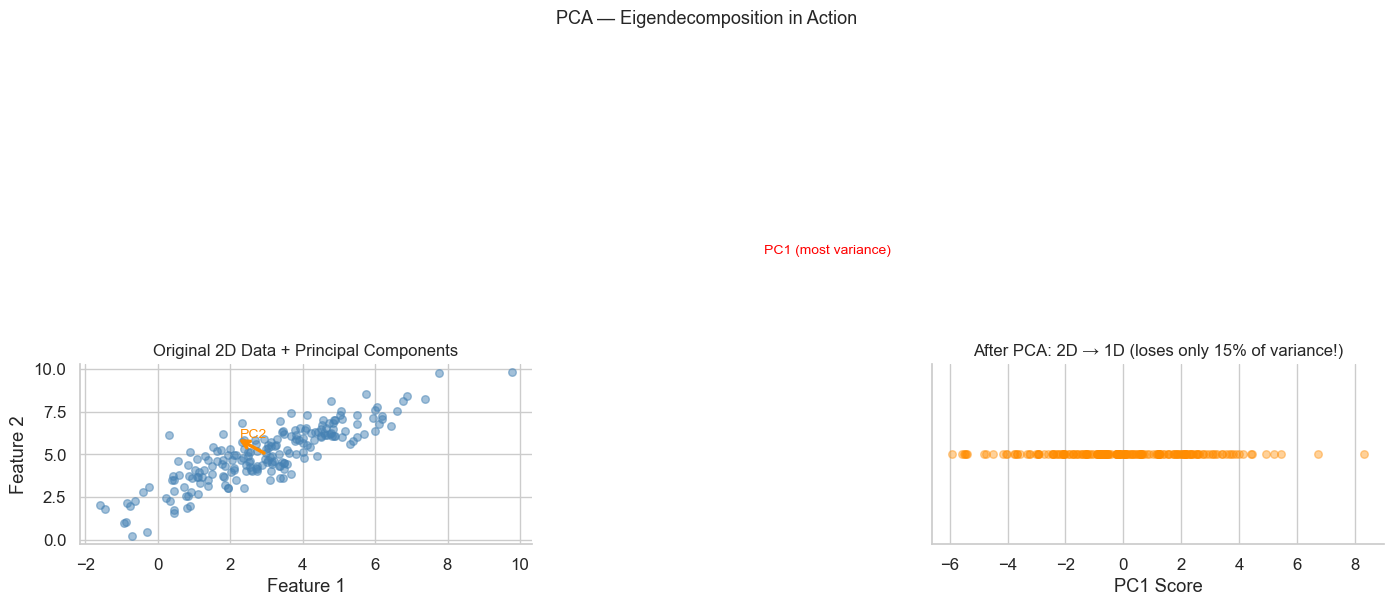

In [54]:
# ============================================================
# CELL 14 — Eigenvalues & Eigenvectors → PCA from Scratch
# PCA: find directions of maximum variance using eigendecomposition
# ============================================================

# Generate synthetic 2D data with a strong correlation (elongated cloud)
np.random.seed(42)                       # Set seed for reproducibility
n_samples = 200
mean = [3, 5]                            # Center of the data cloud
cov = [[4, 3], [3, 3]]                   # Covariance matrix: large variance in x, correlated with y
data = np.random.multivariate_normal(mean, cov, n_samples)   # Generate 2D data

# PCA Step 1: Center the data (subtract mean)
data_centered = data - data.mean(axis=0)   # axis=0 means mean across rows (per column)

# PCA Step 2: Compute the covariance matrix
# Covariance matrix tells us how features vary together
cov_matrix = np.cov(data_centered.T)       # .T because np.cov expects features as rows
print(f"Covariance Matrix:\n{np.round(cov_matrix, 3)}")

# PCA Step 3: Eigendecomposition of covariance matrix
# eigenvalues: amount of variance captured by each principal component
# eigenvectors: directions of the principal components
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)   # The key linear algebra step!

print(f"\nEigenvalues:  {np.round(eigenvalues, 3)}")
print(f"  → PC1 explains {eigenvalues[0]/sum(eigenvalues)*100:.1f}% of variance")
print(f"  → PC2 explains {eigenvalues[1]/sum(eigenvalues)*100:.1f}% of variance")
print(f"\nEigenvectors (columns = principal component directions):\n{np.round(eigenvectors, 3)}")

# PCA Step 4: Sort by eigenvalue (largest first = most important PC)
sort_idx = np.argsort(eigenvalues)[::-1]   # Argsort in descending order
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]   # Reorder columns accordingly

# PCA Step 5: Project data onto principal components (dimensionality reduction)
# Take only top-1 PC to reduce from 2D to 1D
pc1 = eigenvectors[:, 0]                  # First principal component direction
data_1d = data_centered @ pc1.reshape(-1, 1)  # Project: matrix multiply to get 1D

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Original 2D data with principal component arrows
ax1.scatter(data[:, 0], data[:, 1], alpha=0.5, color='steelblue', s=30)
scale = 3   # Scale eigenvectors for visibility
for i, (ev, label, col) in enumerate(zip(eigenvectors.T,
                                          ['PC1 (most variance)', 'PC2'],
                                          ['red', 'darkorange'])):
    ax1.annotate('', xy=(mean[0] + scale*eigenvalues[i]*ev[0],
                         mean[1] + scale*eigenvalues[i]*ev[1]),
                 xytext=mean,
                 arrowprops=dict(arrowstyle='->', color=col, lw=2.5))
    ax1.text(mean[0] + scale*eigenvalues[i]*ev[0] + 0.1,
             mean[1] + scale*eigenvalues[i]*ev[1], label, color=col, fontsize=10)
ax1.set_title('Original 2D Data + Principal Components', fontsize=12)
ax1.set_xlabel('Feature 1')
ax1.set_ylabel('Feature 2')

# After PCA: 1D projection (we reduced 2 features → 1 feature)
ax2.scatter(data_1d, np.zeros_like(data_1d), alpha=0.4, color='darkorange', s=30)
ax2.set_title('After PCA: 2D → 1D (loses only 15% of variance!)', fontsize=12)
ax2.set_xlabel('PC1 Score')
ax2.set_yticks([])

plt.suptitle(' PCA — Eigendecomposition in Action', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Original image shape: (60, 80)
U shape:     (60, 60)
sigma shape: (60,)  (singular values, sorted descending)
Vt shape:    (60, 80)

Top 10 singular values: [23.23  2.03  1.98  1.95  1.93  1.85  1.82  1.75  1.72  1.65]
Most of the information is in the first few singular values!


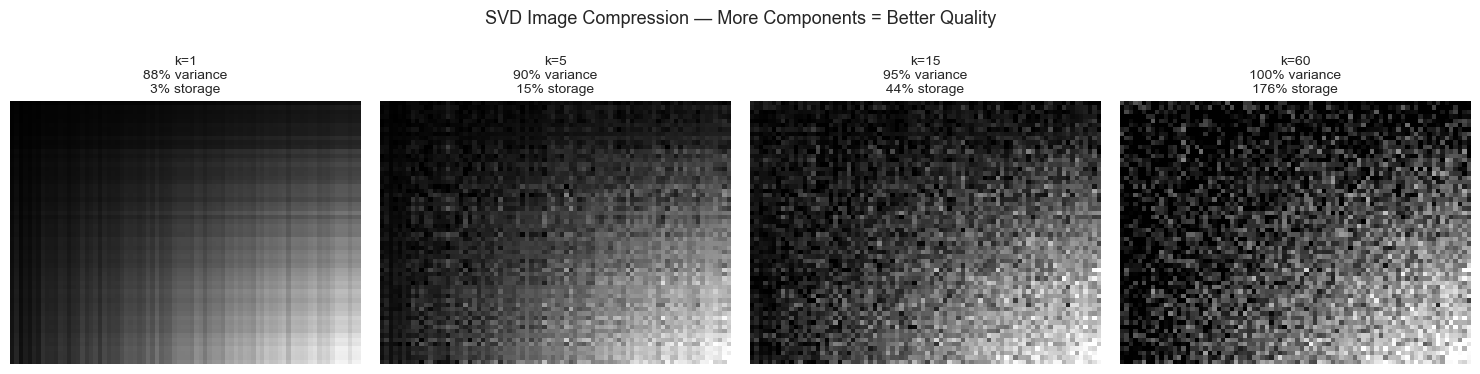


 SVD is also used in: Recommendation Systems (matrix factorization),
   Latent Semantic Analysis (NLP), and noise reduction.


In [55]:
# ============================================================
# CELL 15 — SVD: Image Compression Demo
# SVD: A = U·Σ·Vᵀ  → Keep only top-k singular values for compression
# ============================================================

# Create a synthetic 'image' (a matrix of pixel values)
np.random.seed(0)
rows, cols = 60, 80
# Make it look like a real image: structured gradients + noise
base = np.outer(np.linspace(0, 1, rows), np.linspace(0, 1, cols))  # Gradient
img = base + 0.15 * np.random.randn(rows, cols)   # Add noise
img = np.clip(img, 0, 1)  # Clip to valid pixel range [0, 1]

# Compute SVD: decomposes image into U, sigma, Vt
# U: left singular vectors (row patterns)
# sigma: singular values (importance of each component, sorted descending)
# Vt: right singular vectors (column patterns)
U, sigma, Vt = np.linalg.svd(img, full_matrices=False)
print(f"Original image shape: {img.shape}")
print(f"U shape:     {U.shape}")
print(f"sigma shape: {sigma.shape}  (singular values, sorted descending)")
print(f"Vt shape:    {Vt.shape}")
print(f"\nTop 10 singular values: {np.round(sigma[:10], 2)}")
print(f"Most of the information is in the first few singular values!")

# Reconstruct the image using only the top k components
def reconstruct_image(U, sigma, Vt, k):
    """Reconstruct image using only top-k singular values."""
    # Keep only the first k singular values and corresponding vectors
    return U[:, :k] @ np.diag(sigma[:k]) @ Vt[:k, :]  # Rank-k approximation

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
k_values = [1, 5, 15, 60]    # Different levels of compression

for ax, k in zip(axes, k_values):
    if k < len(sigma):
        recon = reconstruct_image(U, sigma, Vt, k)
    else:
        recon = img  # Full reconstruction
    # Explained variance: sum of squares of top-k / total
    explained = (sigma[:k]**2).sum() / (sigma**2).sum() * 100
    compression = k * (rows + cols + 1) / (rows * cols) * 100  # Storage ratio
    ax.imshow(recon, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'k={k}\n{explained:.0f}% variance\n{compression:.0f}% storage', fontsize=10)
    ax.axis('off')

plt.suptitle('SVD Image Compression — More Components = Better Quality',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print("\n SVD is also used in: Recommendation Systems (matrix factorization),")
print("   Latent Semantic Analysis (NLP), and noise reduction.")

---
# SECTION 6 — Probability Foundations & Counting
### Day 22 | Module 5

**What your instructor showed on the whiteboard:**
- Probability axioms, sample space, events
- Permutations (order matters) and Combinations (order doesn't matter)
- Monte Carlo estimation of π

**Why it matters in ML:**
- ML outputs are **probabilities** (Logistic Regression gives P(class=1|features))
- **Dropout** in neural networks is probabilistic (each neuron randomly dropped with prob p)
- **Random sampling** is used everywhere: train/test splits, bootstrap, stochastic gradient descent

In [56]:
# ============================================================
# CELL 16 — Monte Carlo Estimation of π
# Throw random darts at a unit square. Count those inside a circle.
# Ratio = π/4  →  π ≈ 4 × (darts_inside / total_darts)
# ============================================================

import math

np.random.seed(42)    # Reproducible random numbers
n_darts = 10000       # Total number of random dart throws

# Generate random (x, y) coordinates in the square [-1, 1] x [-1, 1]
x_darts = np.random.uniform(-1, 1, n_darts)   # Random x positions
y_darts = np.random.uniform(-1, 1, n_darts)   # Random y positions

# A dart is inside the unit circle if x² + y² ≤ 1
distance_sq = x_darts**2 + y_darts**2         # Distance² from origin for each dart
inside_circle = distance_sq <= 1              # Boolean: True if inside circle

# Estimate π using the area ratio
# Area of circle / Area of square = π/4
# → π ≈ 4 × (number inside circle / total darts)
pi_estimate = 4 * inside_circle.sum() / n_darts

print(f"Monte Carlo π Estimation with {n_darts:,} darts")
print(f"  Darts inside circle: {inside_circle.sum():,}")
print(f"  Estimated π = {pi_estimate:.5f}")
print(f"  True π      = {math.pi:.5f}")
print(f"  Error       = {abs(pi_estimate - math.pi):.5f}")

# How does accuracy improve with more darts?
dart_counts = [100, 500, 1000, 5000, 10000, 50000]
print(f"\n{'Darts':>8} | {'π Estimate':>12} | {'Error':>10}")
print("-" * 38)
for n in dart_counts:
    x_tmp = np.random.uniform(-1, 1, n)
    y_tmp = np.random.uniform(-1, 1, n)
    inside = (x_tmp**2 + y_tmp**2) <= 1
    pi_est = 4 * inside.sum() / n
    print(f"{n:>8,} | {pi_est:>12.5f} | {abs(pi_est - math.pi):>10.5f}")

print(f"\n More samples → better estimate. This is the Law of Large Numbers!")
print(f"   ML uses this principle: more training data → better model estimates.")

Monte Carlo π Estimation with 10,000 darts
  Darts inside circle: 7,837
  Estimated π = 3.13480
  True π      = 3.14159
  Error       = 0.00679

   Darts |   π Estimate |      Error
--------------------------------------
     100 |      3.32000 |    0.17841
     500 |      3.12800 |    0.01359
   1,000 |      3.11200 |    0.02959
   5,000 |      3.17040 |    0.02881
  10,000 |      3.13320 |    0.00839
  50,000 |      3.15272 |    0.01113

 More samples → better estimate. This is the Law of Large Numbers!
   ML uses this principle: more training data → better model estimates.


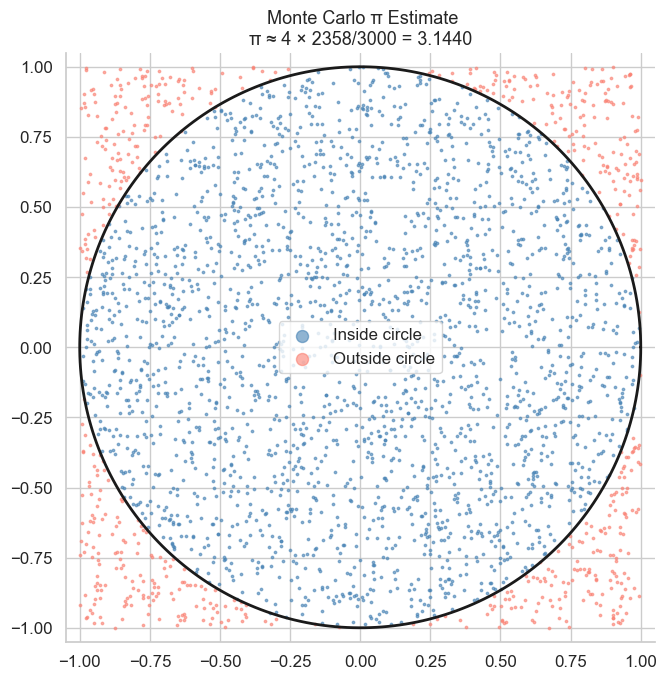

In [57]:
# ============================================================
# CELL 17 — Visualize Monte Carlo Simulation
# ============================================================

np.random.seed(42)
n_plot = 3000   # Plot 3000 darts for a clear visual
xp = np.random.uniform(-1, 1, n_plot)
yp = np.random.uniform(-1, 1, n_plot)
inside = (xp**2 + yp**2) <= 1

fig, ax = plt.subplots(figsize=(7, 7))
# Blue dots inside circle, red dots outside
ax.scatter(xp[inside],  yp[inside],  color='steelblue', s=3, alpha=0.6, label='Inside circle')
ax.scatter(xp[~inside], yp[~inside], color='salmon',    s=3, alpha=0.6, label='Outside circle')
# Draw the quarter circle
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k-', lw=2)   # Unit circle boundary
ax.set_xlim(-1.05, 1.05)
ax.set_ylim(-1.05, 1.05)
ax.set_aspect('equal')
ax.set_title(f' Monte Carlo π Estimate\nπ ≈ 4 × {inside.sum()}/{n_plot} = {4*inside.sum()/n_plot:.4f}',
             fontsize=13)
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

---
# SECTION 7 — Conditional Probability & Bayes' Theorem
### Day 23 | Module 5

**What your instructor showed on the whiteboard:**
- Conditional probability: P(A|B) = P(A∩B) / P(B)
- Bayes' Theorem: P(A|B) = P(B|A)·P(A) / P(B)
- Medical test example — base rate neglect

**Why it matters in ML:**
- **Naive Bayes classifier** is built entirely on Bayes' theorem
- **Bayesian optimization** for hyperparameter tuning uses Bayes theorem to decide where to search next
- **Spam filters** use Bayes' theorem (posterior = prior × likelihood)

In [58]:
# ============================================================
# CELL 18 — Bayes' Theorem: Medical Test Example
# Even a 99% accurate test has many false positives for rare diseases
# ============================================================

def bayes_medical_test(prevalence, sensitivity, specificity):
    """
    Bayes' Theorem applied to medical testing.
    
    P(Disease | Positive Test) = P(Positive|Disease) × P(Disease) / P(Positive)
    
    Args:
        prevalence:   P(Disease)  — how common the disease is in population
        sensitivity:  P(Pos|Disease) — test catches true positives (recall/TPR)
        specificity:  P(Neg|No Disease) — test correctly rules out negatives (TNR)
    Returns:
        P(Disease | Positive Test) — posterior probability
    """
    P_disease = prevalence                           # Prior probability of having disease
    P_no_disease = 1 - prevalence                   # Prior probability of NOT having disease
    P_pos_given_disease = sensitivity               # Likelihood: P(Positive | Disease)
    P_pos_given_no_disease = 1 - specificity        # False positive rate: P(Positive | No Disease)
    
    # Total probability of testing positive (denominator — normalization constant)
    P_positive = (P_pos_given_disease * P_disease         # True positives
                + P_pos_given_no_disease * P_no_disease)  # False positives
    
    # Bayes theorem: P(Disease | Positive)
    posterior = (P_pos_given_disease * P_disease) / P_positive
    return posterior

print("BAYES' THEOREM: Medical Test Paradox")
print("=" * 55)
print("\nScenario: Test has 99% sensitivity AND 99% specificity")
print("Question: If you test positive, what's the chance you're sick?")
print()

# Test the same 99% accurate test on diseases with different prevalence
test_cases = [
    (0.001, 0.99, 0.99, "Rare disease (0.1% prevalence)"),
    (0.01,  0.99, 0.99, "Uncommon disease (1% prevalence)"),
    (0.10,  0.99, 0.99, "Common disease (10% prevalence)"),
    (0.50,  0.99, 0.99, "Very common disease (50% prevalence)"),
]

print(f"{'Scenario':<40} | {'P(Sick|Positive)':>18}")
print("-" * 62)
for prev, sens, spec, name in test_cases:
    posterior = bayes_medical_test(prev, sens, spec)
    print(f"{name:<40} | {posterior*100:>16.1f}%")

print("\n Surprising result: A 99% accurate test gives only ~9% actual probability")
print("   of having a rare disease if you test positive!")
print("   The rarity of the disease (base rate) overwhelms the test accuracy.")
print("\n ML Connection: Imbalanced classification has the same math.")
print("   A fraud model with 99% accuracy might still miss most actual frauds")
print("   if fraud only happens 0.1% of the time. This is why AUC-PR matters!")

BAYES' THEOREM: Medical Test Paradox

Scenario: Test has 99% sensitivity AND 99% specificity
Question: If you test positive, what's the chance you're sick?

Scenario                                 |   P(Sick|Positive)
--------------------------------------------------------------
Rare disease (0.1% prevalence)           |              9.0%
Uncommon disease (1% prevalence)         |             50.0%
Common disease (10% prevalence)          |             91.7%
Very common disease (50% prevalence)     |             99.0%

 Surprising result: A 99% accurate test gives only ~9% actual probability
   of having a rare disease if you test positive!
   The rarity of the disease (base rate) overwhelms the test accuracy.

 ML Connection: Imbalanced classification has the same math.
   A fraud model with 99% accuracy might still miss most actual frauds
   if fraud only happens 0.1% of the time. This is why AUC-PR matters!


---
# SECTION 8 — Random Variables & Discrete Distributions
### Day 24 | Module 5

**What your instructor showed on the whiteboard:**
- Bernoulli, Binomial, and Poisson distributions
- PMF (probability mass function) and CDF (cumulative distribution function)
- Expected value E[X] and Variance Var[X]

**Why it matters in ML:**
- **Bernoulli distribution** models binary classification outcomes (0 or 1)
- **Binomial distribution** models how many successes in n trials → used in evaluating classifiers
- **Poisson distribution** models event counts → used in recommender systems, network traffic modeling

In [59]:
# ============================================================
# CELL 19 — Discrete Distributions: Binomial and Poisson
# scipy.stats makes it easy to work with any distribution
# ============================================================

from scipy import stats

# --- BINOMIAL DISTRIBUTION ---
# Scenario: A classifier has 70% accuracy. If we test it on 20 samples,
# what's the distribution of correct predictions?
n_trials = 20     # Test on 20 samples
p_success = 0.7   # 70% accuracy per sample

binom_dist = stats.binom(n=n_trials, p=p_success)   # Create the distribution object
k_values = np.arange(0, 21)                          # Possible number of correct: 0 to 20
pmf_vals = binom_dist.pmf(k_values)                  # Probability of each outcome

print(f"BINOMIAL DISTRIBUTION: n={n_trials}, p={p_success}")
print(f"  Expected correct predictions: E[X] = n·p = {binom_dist.mean():.1f}")
print(f"  Standard deviation:           σ = {binom_dist.std():.2f}")
print(f"  P(X = 14 correct) = {binom_dist.pmf(14):.4f}")
print(f"  P(X ≥ 16 correct) = {1 - binom_dist.cdf(15):.4f}")

# --- POISSON DISTRIBUTION ---
# Scenario: An e-commerce site gets on average 150 orders per hour.
# What's the probability of getting exactly 160 orders in one hour?
lambda_orders = 150   # Average rate (λ)
poisson_dist = stats.poisson(mu=lambda_orders)   # Create Poisson distribution

print(f"\nPOISSON DISTRIBUTION: λ={lambda_orders} (avg orders/hour)")
print(f"  E[X] = λ = {poisson_dist.mean():.0f}")
print(f"  Var[X] = λ = {poisson_dist.var():.0f}  (unique property: mean = variance)")
print(f"  P(X = 160 orders) = {poisson_dist.pmf(160):.5f}")
print(f"  P(X > 180 orders) = {1 - poisson_dist.cdf(180):.5f}")
print(f"  P(150 ≤ X ≤ 160)  = {poisson_dist.cdf(160) - poisson_dist.cdf(149):.4f}")

print(f"\n ML Connection: Poisson distribution is used to model")
print(f"   - Click counts on ads (Poisson click model)")
print(f"   - Words in a document (text generation models)")
print(f"   - Anomaly detection: orders far from expected λ may be bot attacks")

BINOMIAL DISTRIBUTION: n=20, p=0.7
  Expected correct predictions: E[X] = n·p = 14.0
  Standard deviation:           σ = 2.05
  P(X = 14 correct) = 0.1916
  P(X ≥ 16 correct) = 0.2375

POISSON DISTRIBUTION: λ=150 (avg orders/hour)
  E[X] = λ = 150
  Var[X] = λ = 150  (unique property: mean = variance)
  P(X = 160 orders) = 0.02275
  P(X > 180 orders) = 0.00764
  P(150 ≤ X ≤ 160)  = 0.3163

 ML Connection: Poisson distribution is used to model
   - Click counts on ads (Poisson click model)
   - Words in a document (text generation models)
   - Anomaly detection: orders far from expected λ may be bot attacks


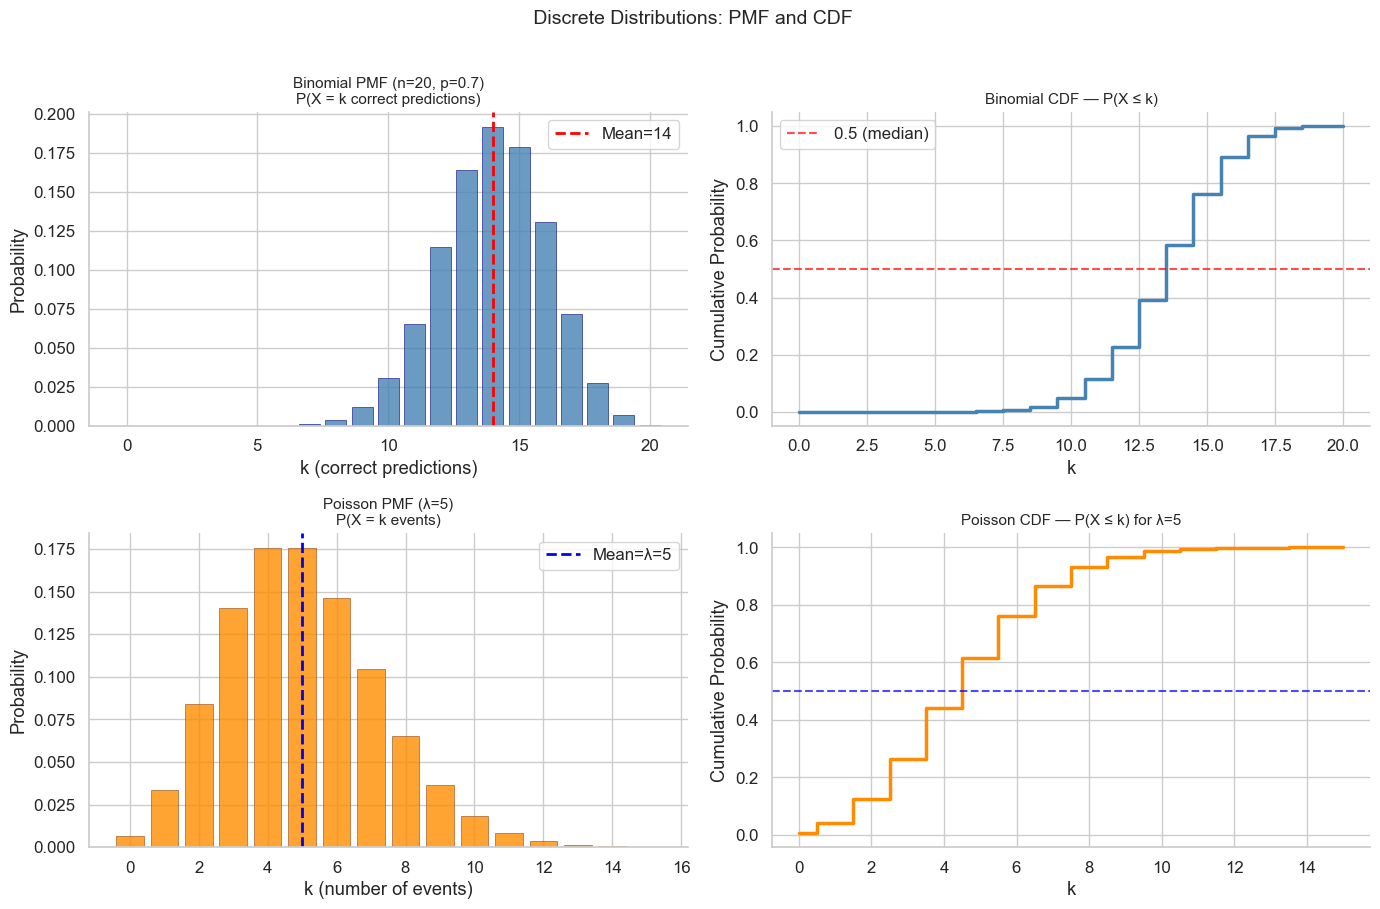

In [60]:
# ============================================================
# CELL 20 — Plot PMF and CDF for Both Distributions
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Row 1: Binomial
k_binom = np.arange(0, 21)
pmf_binom = binom_dist.pmf(k_binom)
cdf_binom = binom_dist.cdf(k_binom)

axes[0,0].bar(k_binom, pmf_binom, color='steelblue', alpha=0.8, edgecolor='navy', linewidth=0.5)
axes[0,0].axvline(binom_dist.mean(), color='red', lw=2, linestyle='--', label=f'Mean={binom_dist.mean():.0f}')
axes[0,0].set_title('Binomial PMF (n=20, p=0.7)\nP(X = k correct predictions)', fontsize=11)
axes[0,0].set_xlabel('k (correct predictions)')
axes[0,0].set_ylabel('Probability')
axes[0,0].legend()

axes[0,1].step(k_binom, cdf_binom, color='steelblue', lw=2.5, where='mid')
axes[0,1].axhline(0.5, color='red', lw=1.5, linestyle='--', alpha=0.7, label='0.5 (median)')
axes[0,1].set_title('Binomial CDF — P(X ≤ k)', fontsize=11)
axes[0,1].set_xlabel('k')
axes[0,1].set_ylabel('Cumulative Probability')
axes[0,1].legend()

# Row 2: Poisson (use smaller lambda for visibility)
lam_plot = 5
pois_plot = stats.poisson(mu=lam_plot)
k_pois = np.arange(0, 16)
pmf_pois = pois_plot.pmf(k_pois)
cdf_pois = pois_plot.cdf(k_pois)

axes[1,0].bar(k_pois, pmf_pois, color='darkorange', alpha=0.8, edgecolor='saddlebrown', linewidth=0.5)
axes[1,0].axvline(lam_plot, color='blue', lw=2, linestyle='--', label=f'Mean=λ={lam_plot}')
axes[1,0].set_title(f'Poisson PMF (λ={lam_plot})\nP(X = k events)', fontsize=11)
axes[1,0].set_xlabel('k (number of events)')
axes[1,0].set_ylabel('Probability')
axes[1,0].legend()

axes[1,1].step(k_pois, cdf_pois, color='darkorange', lw=2.5, where='mid')
axes[1,1].axhline(0.5, color='blue', lw=1.5, linestyle='--', alpha=0.7)
axes[1,1].set_title(f'Poisson CDF — P(X ≤ k) for λ={lam_plot}', fontsize=11)
axes[1,1].set_xlabel('k')
axes[1,1].set_ylabel('Cumulative Probability')

plt.suptitle(' Discrete Distributions: PMF and CDF', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
# SECTION 9 — Continuous Distributions & the Normal Distribution
###  Day 25 | Module 5

**What your instructor showed on the whiteboard:**
- PDF integrates to 1 (unlike PMF which sums to 1)
- Normal distribution bell curve: 68-95-99.7 rule
- Z-score standardization

**Why it matters in ML:**
- **Feature scaling / Standardization** relies on the Normal distribution (Z-score normalization)
- **Residuals** in Linear Regression should be normally distributed (regression assumption)
- Neural network **weight initialization** uses Normal distribution (Xavier, He initialization)

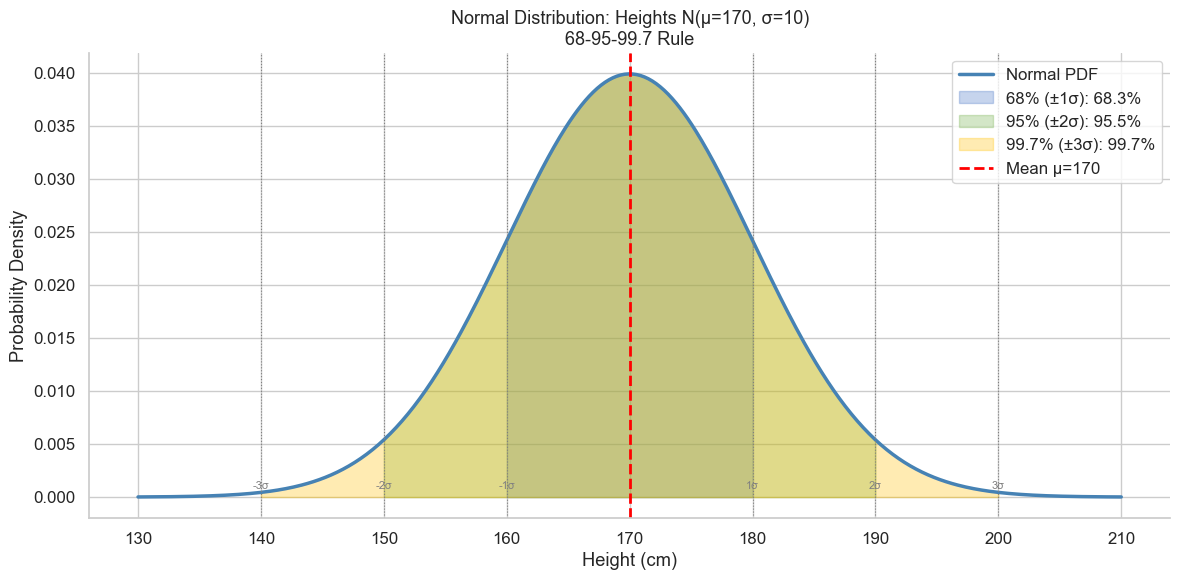

PROBABILITY LOOKUPS using scipy.stats.norm:
  P(height > 190cm) = P(Z > 2σ) = 0.0228
  P(160 ≤ height ≤ 180) = 0.6827
  90th percentile = 182.8 cm (height_dist.ppf(0.90))

 ML Connection: StandardScaler in sklearn transforms features to N(0,1)
   It computes Z = (X - μ) / σ for each feature → same as standardizing to Normal


In [61]:
# ============================================================
# CELL 21 — Normal Distribution and the 68-95-99.7 Rule
# ============================================================

# Create a Normal distribution object with mean=170 (height in cm), std=10
mu, sigma_val = 170, 10
height_dist = stats.norm(loc=mu, scale=sigma_val)   # Normal(μ=170, σ=10)

x_range = np.linspace(130, 210, 500)   # x values for plotting
pdf_vals = height_dist.pdf(x_range)    # PDF value at each x

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_range, pdf_vals, 'steelblue', lw=2.5, label='Normal PDF')

# Shade regions for 1σ, 2σ, 3σ
colors_shade = ['#4472C4', '#70AD47', '#FFC000']   # Blue, green, yellow
sigma_ranges = [1, 2, 3]
sigma_labels = ['68% (±1σ)', '95% (±2σ)', '99.7% (±3σ)']
probs = [0.6827, 0.9545, 0.9973]

for sr, col, lab, prob in zip(sigma_ranges, colors_shade, sigma_labels, probs):
    x_fill = np.linspace(mu - sr*sigma_val, mu + sr*sigma_val, 300)
    ax.fill_between(x_fill, height_dist.pdf(x_fill),
                    alpha=0.3, color=col, label=f'{lab}: {prob*100:.1f}%')

ax.axvline(mu, color='red', lw=2, linestyle='--', label=f'Mean μ={mu}')
ax.set_title(f'Normal Distribution: Heights N(μ={mu}, σ={sigma_val})\n68-95-99.7 Rule', fontsize=13)
ax.set_xlabel('Height (cm)')
ax.set_ylabel('Probability Density')
ax.legend(loc='upper right')
# Annotate σ boundaries
for sr in [1, 2, 3]:
    for sign in [-1, 1]:
        ax.axvline(mu + sign*sr*sigma_val, color='gray', lw=0.8, linestyle=':')
        ax.text(mu + sign*sr*sigma_val, max(pdf_vals)*0.02,
                f'{sign*sr}σ', ha='center', fontsize=8, color='gray')
plt.tight_layout()
plt.show()

# Quick probability lookups
print("PROBABILITY LOOKUPS using scipy.stats.norm:")
print(f"  P(height > 190cm) = P(Z > 2σ) = {1 - height_dist.cdf(190):.4f}")
print(f"  P(160 ≤ height ≤ 180) = {height_dist.cdf(180) - height_dist.cdf(160):.4f}")
# ppf = percent point function (inverse CDF)
print(f"  90th percentile = {height_dist.ppf(0.90):.1f} cm (height_dist.ppf(0.90))")
print(f"\n ML Connection: StandardScaler in sklearn transforms features to N(0,1)")
print(f"   It computes Z = (X - μ) / σ for each feature → same as standardizing to Normal")

In [62]:
# ============================================================
# CELL 22 — Z-Score Standardization: What StandardScaler Does
# This is the preprocessing step done before KNN, SVM, Neural Nets
# ============================================================

# Simulate a small dataset with features of very different scales
np.random.seed(42)
age    = np.random.normal(35, 8, 200)       # Age in years: mean=35, std=8
income = np.random.normal(60000, 15000, 200) # Income: mean=60k, std=15k
bmi    = np.random.normal(25, 4, 200)        # BMI: mean=25, std=4

# Z-score standardization formula: z = (x - mean) / std
def zscore(arr):
    """Standardize to mean=0, std=1."""
    return (arr - arr.mean()) / arr.std()   # Subtract mean, divide by std

age_z    = zscore(age)
income_z = zscore(income)
bmi_z    = zscore(bmi)

print("FEATURE STANDARDIZATION (Z-Score)")
print("=" * 60)
print(f"\n{'Feature':<10} | {'Before: mean':>13} | {'Before: std':>12} | {'After: mean':>12} | {'After: std':>11}")
print("-" * 68)
for name, raw, std in [('Age', age, age_z), ('Income', income, income_z), ('BMI', bmi, bmi_z)]:
    print(f"{name:<10} | {raw.mean():>13.2f} | {raw.std():>12.2f} | {std.mean():>12.4f} | {std.std():>11.4f}")

print(f"\n After standardization: every feature has mean≈0 and std≈1")
print(f"   Now no single feature dominates due to scale differences.")
print(f"\n CRITICAL for: KNN, SVM, Logistic Regression, Neural Networks")
print(f"   NOT needed for: Decision Trees, Random Forests (tree-based models are scale-invariant)")

FEATURE STANDARDIZATION (Z-Score)

Feature    |  Before: mean |  Before: std |  After: mean |  After: std
--------------------------------------------------------------------
Age        |         34.67 |         7.43 |      -0.0000 |      1.0000
Income     |      61288.02 |     14768.00 |      -0.0000 |      1.0000
BMI        |         24.66 |         3.97 |      -0.0000 |      1.0000

 After standardization: every feature has mean≈0 and std≈1
   Now no single feature dominates due to scale differences.

 CRITICAL for: KNN, SVM, Logistic Regression, Neural Networks
   NOT needed for: Decision Trees, Random Forests (tree-based models are scale-invariant)


---
# SECTION 10 — Statistical Measures & Correlation
###  Day 26 | Module 5

**What your instructor showed on the whiteboard:**
- Mean, median, variance, standard deviation
- Covariance matrix
- Pearson and Spearman correlation
- Anscombe's quartet (always plot your data!)

**Why it matters in ML:**
- **Correlation analysis** is the first step in feature selection
- **Covariance matrix** is the foundation of PCA
- Highly correlated features cause **multicollinearity** in Linear Regression (VIF)

In [63]:
# ============================================================
# CELL 23 — Complete Statistical Summary on Real Data
# Using Health Insurance dataset (relevant for Day 29 project)
# ============================================================

# Generate synthetic health insurance data (mimics the real dataset structure)
np.random.seed(42)
n = 400
# Simulate realistic insurance data
age     = np.random.randint(18, 65, n)
bmi_arr = np.random.normal(28, 6, n).clip(15, 55)   # BMI distribution
children = np.random.choice([0, 1, 2, 3, 4, 5], n, p=[0.4, 0.25, 0.2, 0.1, 0.04, 0.01])
smoker  = np.random.choice([0, 1], n, p=[0.8, 0.2])  # 20% smokers
# Smokers have much higher charges
base_charge = 2000 + 250*age + 400*bmi_arr + 500*children
charges = base_charge * (1 + 3.5 * smoker) + np.random.normal(0, 2000, n)
charges = charges.clip(1000, 70000)

df = pd.DataFrame({'age': age, 'bmi': bmi_arr, 'children': children,
                   'smoker': smoker, 'charges': charges})

print("DESCRIPTIVE STATISTICS — Health Insurance Dataset")
print("=" * 60)
print(df.describe().round(2).to_string())

print("\n\nCORRELATION MATRIX (Pearson)")
print("=" * 40)
corr_matrix = df.corr()   # Pearson correlation (linear relationship)
print(corr_matrix.round(3).to_string())

print("\n\n Key Insights:")
print(f"   Correlation(smoker, charges) = {corr_matrix.loc['smoker','charges']:.3f}  ← STRONG positive")
print(f"   Correlation(age, charges)    = {corr_matrix.loc['age','charges']:.3f}  ← moderate positive")
print(f"   Correlation(bmi, charges)    = {corr_matrix.loc['bmi','charges']:.3f}  ← moderate positive")
print(f"\n Smoking is the strongest predictor of insurance charges!")

DESCRIPTIVE STATISTICS — Health Insurance Dataset
          age     bmi  children  smoker   charges
count  400.00  400.00    400.00  400.00    400.00
mean    41.30   28.18      1.21    0.18  32393.84
std     13.42    6.34      1.24    0.38  18148.62
min     18.00   15.00      0.00    0.00  11146.68
25%     30.00   23.79      0.00    0.00  21468.19
50%     42.00   28.34      1.00    0.00  25340.73
75%     52.00   32.64      2.00    0.00  30813.47
max     64.00   47.12      5.00    1.00  70000.00


CORRELATION MATRIX (Pearson)
            age    bmi  children  smoker  charges
age       1.000 -0.029     0.026   0.035    0.184
bmi      -0.029  1.000     0.026   0.049    0.170
children  0.026  0.026     1.000  -0.037   -0.002
smoker    0.035  0.049    -0.037   1.000    0.972
charges   0.184  0.170    -0.002   0.972    1.000


 Key Insights:
   Correlation(smoker, charges) = 0.972  ← STRONG positive
   Correlation(age, charges)    = 0.184  ← moderate positive
   Correlation(bmi, charges)    

ANSCOMBE'S QUARTET — Same statistics, different shapes!
Dataset      |  mean(x) |  mean(y) |   std(x) |   std(y) |        r
------------------------------------------------------------
I            |     9.00 |     7.50 |     3.32 |     2.03 |    0.816
II           |     9.00 |     7.50 |     3.32 |     2.03 |    0.816
III          |     9.00 |     7.50 |     3.32 |     2.03 |    0.816
IV           |     9.00 |     7.50 |     3.32 |     2.03 |    0.817


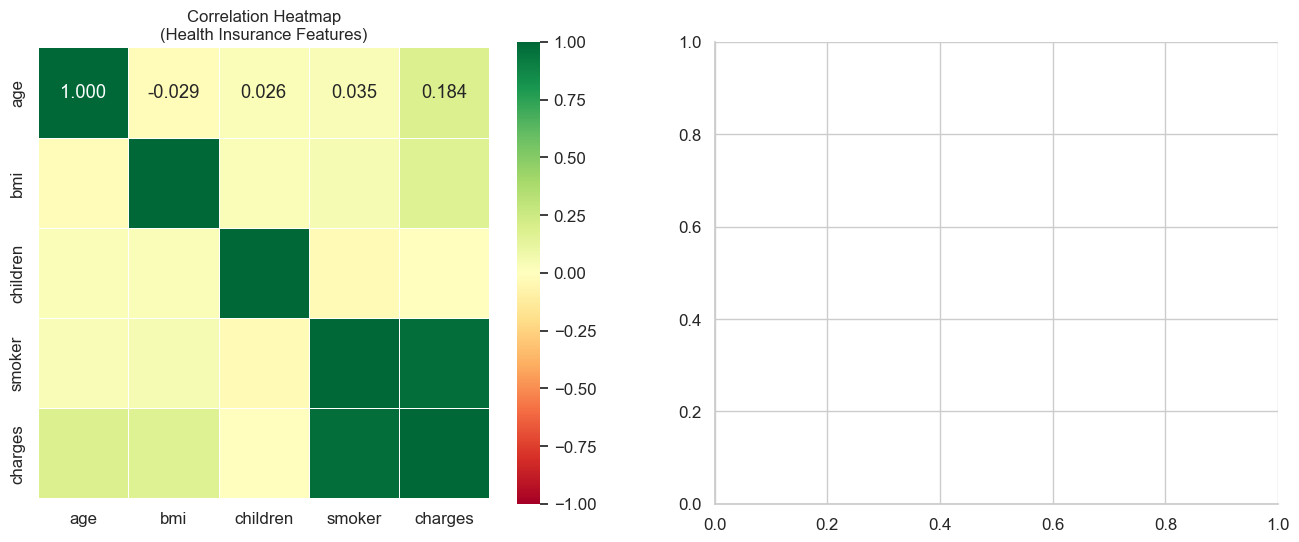

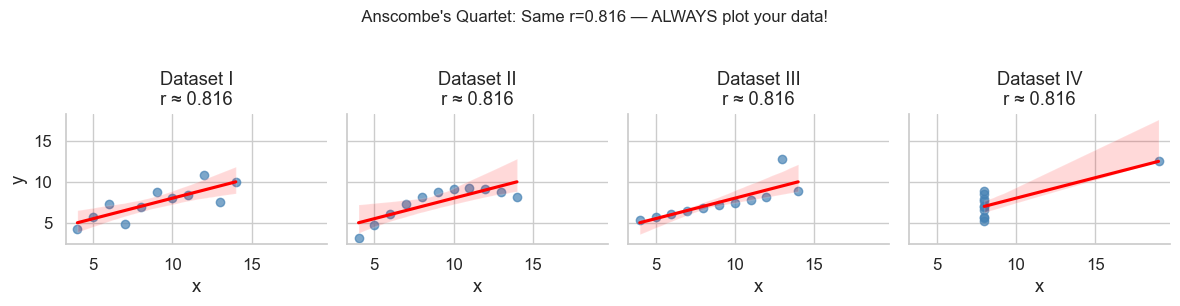

In [64]:
# ============================================================
# CELL 24 — Correlation Heatmap + Anscombe's Quartet Warning
# Anscombe's quartet: 4 datasets with identical statistics but very different shapes
# ============================================================

fig = plt.figure(figsize=(16, 6))

# Left: Correlation heatmap of insurance data
ax1 = fig.add_subplot(1, 2, 1)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # Only lower triangle
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=ax1, square=True, linewidths=0.5)
ax1.set_title('Correlation Heatmap\n(Health Insurance Features)', fontsize=12)

# Right: Anscombe's Quartet — same r=0.816 for all 4 datasets, very different shapes!
anscombe = sns.load_dataset('anscombe')   # Classic dataset built into seaborn
ax2 = fig.add_subplot(1, 2, 2)
# For simplicity, show correlation for each dataset group
print("ANSCOMBE'S QUARTET — Same statistics, different shapes!")
print(f"{'Dataset':<12} | {'mean(x)':>8} | {'mean(y)':>8} | {'std(x)':>8} | {'std(y)':>8} | {'r':>8}")
print("-" * 60)
for name, group in anscombe.groupby('dataset'):
    r, _ = stats.pearsonr(group['x'], group['y'])   # Pearson r
    print(f"{name:<12} | {group['x'].mean():>8.2f} | {group['y'].mean():>8.2f} | "
          f"{group['x'].std():>8.2f} | {group['y'].std():>8.2f} | {r:>8.3f}")

# Plot all 4 Anscombe datasets
g = sns.FacetGrid(anscombe, col='dataset', col_wrap=4, height=3, aspect=1)
g.map(plt.scatter, 'x', 'y', alpha=0.7, color='steelblue')
g.map(sns.regplot, 'x', 'y', scatter=False, color='red')   # Linear fit line
g.set_titles(col_template='Dataset {col_name}\nr ≈ 0.816')
g.figure.suptitle('  Anscombe\'s Quartet: Same r=0.816 — ALWAYS plot your data!',
                   fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

fig.tight_layout()
plt.show()

---
# SECTION 11 — Hypothesis Testing & t-Tests
### Day 27 | Module 5

**What your instructor showed on the whiteboard:**
- Null hypothesis H₀ and Alternative H₁
- p-value interpretation (p < 0.05)
- t-test, chi-square test, Central Limit Theorem

**Why it matters in ML:**
- **A/B testing** uses t-tests to decide if a new model version is significantly better
- **Feature selection**: hypothesis tests (chi-square, ANOVA F-test) check if features are statistically important
- **Model comparison**: Is Random Forest significantly better than Logistic Regression on this data?

CENTRAL LIMIT THEOREM DEMO
Population distribution: Exponential (very right-skewed)
Population mean: 1.992, std: 1.986
Population skewness: 1.992  ← highly positive skewed


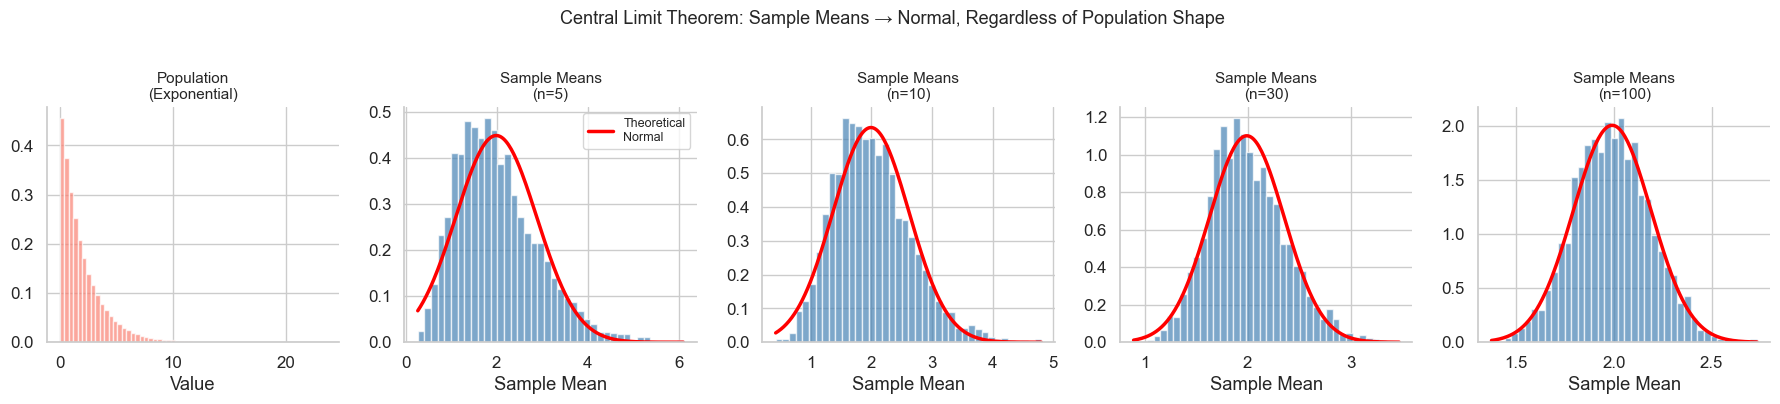


 CLT is WHY t-tests work even when data isn't perfectly normal (with n≥30)


In [65]:
# ============================================================
# CELL 25 — Central Limit Theorem (CLT) Demonstration
# No matter the population distribution, sample means approach Normal
# ============================================================

# Highly skewed population: exponential distribution (like website load times)
np.random.seed(42)
population = np.random.exponential(scale=2, size=100000)   # Very skewed population

print("CENTRAL LIMIT THEOREM DEMO")
print(f"Population distribution: Exponential (very right-skewed)")
print(f"Population mean: {population.mean():.3f}, std: {population.std():.3f}")
print(f"Population skewness: {stats.skew(population):.3f}  ← highly positive skewed")

# Draw many samples of different sizes, compute each sample's MEAN
sample_sizes = [5, 10, 30, 100]       # Different sample sizes
n_repetitions = 3000                  # How many samples to draw for each size

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

# First subplot: the raw skewed population
axes[0].hist(population, bins=60, color='salmon', alpha=0.7, density=True)
axes[0].set_title('Population\n(Exponential)', fontsize=11)
axes[0].set_xlabel('Value')

# Remaining subplots: distribution of sample means for each sample size
for i, n_samples in enumerate(sample_sizes, 1):
    # Draw n_repetitions samples, each of size n_samples, compute each sample's mean
    sample_means = [np.random.choice(population, n_samples, replace=False).mean()
                    for _ in range(n_repetitions)]
    sample_means = np.array(sample_means)
    
    # Theoretical Normal distribution for sample means (from CLT)
    # E[X̄] = μ, Std[X̄] = σ/√n (standard error)
    theoretical_mean = population.mean()
    theoretical_std  = population.std() / np.sqrt(n_samples)  # Standard Error
    
    # Plot histogram of sample means
    axes[i].hist(sample_means, bins=40, density=True, color='steelblue', alpha=0.7)
    # Overlay theoretical Normal curve
    x_line = np.linspace(sample_means.min(), sample_means.max(), 200)
    axes[i].plot(x_line, stats.norm.pdf(x_line, theoretical_mean, theoretical_std),
                'red', lw=2.5, label='Theoretical\nNormal')
    axes[i].set_title(f'Sample Means\n(n={n_samples})', fontsize=11)
    axes[i].set_xlabel('Sample Mean')
    if i == 1:
        axes[i].legend(fontsize=9)

plt.suptitle(' Central Limit Theorem: Sample Means → Normal, Regardless of Population Shape',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print("\n CLT is WHY t-tests work even when data isn't perfectly normal (with n≥30)")

In [66]:
# ============================================================
# CELL 26 — Two-Sample t-Test: Smokers vs Non-smokers
# Hypothesis testing to compare insurance charges between groups
# ============================================================

# Separate the insurance data by smoking status
smoker_charges    = df[df['smoker'] == 1]['charges'].values    # Charges for smokers
nonsmoker_charges = df[df['smoker'] == 0]['charges'].values    # Charges for non-smokers

print("HYPOTHESIS TEST: Do smokers have significantly higher insurance charges?")
print("=" * 65)
print(f"\nH₀ (Null):        Smokers and non-smokers have the same mean charges")
print(f"H₁ (Alternative): Smokers have HIGHER mean charges (one-tailed test)")
print(f"\nData Summary:")
print(f"  Smokers:     n={len(smoker_charges):3d}, mean=${smoker_charges.mean():>8,.0f}, std=${smoker_charges.std():>7,.0f}")
print(f"  Non-smokers: n={len(nonsmoker_charges):3d}, mean=${nonsmoker_charges.mean():>8,.0f}, std=${nonsmoker_charges.std():>7,.0f}")
print(f"  Mean difference = ${smoker_charges.mean() - nonsmoker_charges.mean():,.0f}")

# Independent two-sample t-test
# equal_var=False → Welch's t-test (safer when group variances differ)
t_stat, p_value = stats.ttest_ind(smoker_charges, nonsmoker_charges,
                                   alternative='greater',  # One-tailed: smokers > non-smokers
                                   equal_var=False)        # Welch's t-test

print(f"\nTwo-Sample t-Test Results (Welch's):")
print(f"  t-statistic = {t_stat:.4f}")
print(f"  p-value     = {p_value:.2e}")
alpha = 0.05  # Significance level
if p_value < alpha:
    print(f"\n REJECT H₀ (p={p_value:.2e} < α=0.05)")
    print(f"   Smokers have STATISTICALLY SIGNIFICANTLY higher insurance charges!")
else:
    print(f"\n FAIL TO REJECT H₀ (p={p_value:.2e} ≥ α=0.05)")

# Effect size: Cohen's d
pooled_std = np.sqrt((smoker_charges.std()**2 + nonsmoker_charges.std()**2) / 2)
cohens_d = (smoker_charges.mean() - nonsmoker_charges.mean()) / pooled_std
print(f"\n  Cohen's d = {cohens_d:.3f}")
magnitude = 'Large' if abs(cohens_d) > 0.8 else 'Medium' if abs(cohens_d) > 0.5 else 'Small'
print(f"  Effect Size: {magnitude} (small<0.2, medium<0.5, large>0.8)")
print(f"\n ML Connection: In A/B testing for ML models, we use t-tests to check")
print(f"   if a new model is significantly better, not just by chance.")

HYPOTHESIS TEST: Do smokers have significantly higher insurance charges?

H₀ (Null):        Smokers and non-smokers have the same mean charges
H₁ (Alternative): Smokers have HIGHER mean charges (one-tailed test)

Data Summary:
  Smokers:     n= 72, mean=$  70,000, std=$      0
  Non-smokers: n=328, mean=$  24,139, std=$  4,699
  Mean difference = $45,861

Two-Sample t-Test Results (Welch's):
  t-statistic = 176.4698
  p-value     = 0.00e+00

 REJECT H₀ (p=0.00e+00 < α=0.05)
   Smokers have STATISTICALLY SIGNIFICANTLY higher insurance charges!

  Cohen's d = 13.801
  Effect Size: Large (small<0.2, medium<0.5, large>0.8)

 ML Connection: In A/B testing for ML models, we use t-tests to check
   if a new model is significantly better, not just by chance.


---
# SECTION 12 — Data Transformations & Handling Skewness
### Day 28 | Module 5

**What your instructor showed on the whiteboard:**
- Positive/negative skewness
- Log, sqrt, Box-Cox transformations
- QQ-plots for normality checking

**Why it matters in ML:**
- Many ML algorithms (Linear Regression, Logistic Regression) assume normally distributed residuals
- Skewed features can hurt gradient descent convergence
- **sklearn's PowerTransformer** automates Box-Cox and Yeo-Johnson transformations

In [67]:
# ============================================================
# CELL 27 — Detecting Skewness and Applying Transformations
# Insurance charges are heavily right-skewed → transform before regression
# ============================================================

charges_raw = df['charges'].values    # Raw insurance charges (heavily skewed)

# Apply different transformations
charges_log   = np.log(charges_raw)             # Log transform: reduces right skew
charges_sqrt  = np.sqrt(charges_raw)            # Square root: milder than log
charges_boxcox, lambda_bc = stats.boxcox(charges_raw)  # Box-Cox: finds optimal λ

print("SKEWNESS ANALYSIS — Insurance Charges")
print("=" * 55)
results = [
    ("Original",       charges_raw,    "No transform"),
    ("Log(charges)",   charges_log,    "log(x)"),
    ("Sqrt(charges)",  charges_sqrt,   "√x"),
    (f"Box-Cox(λ={lambda_bc:.2f})", charges_boxcox, "Box-Cox"),
]

print(f"{'Transform':<22} | {'Skewness':>10} | {'Closer to Normal?':>18}")
print("-" * 58)
for name, arr, method in results:
    skewness = stats.skew(arr)       # Positive = right skew, 0 = symmetric
    normal_q = abs(skewness) < 0.5   # Rule of thumb: |skew| < 0.5 is acceptable
    print(f"{name:<22} | {skewness:>10.3f} | {' Yes' if normal_q else ' Not yet':>18}")

print(f"\nBox-Cox optimal λ = {lambda_bc:.4f}")
print(f"  λ ≈ 0 → log transform; λ ≈ 0.5 → sqrt; λ = 1 → no transform")
print(f"  Box-Cox found λ={lambda_bc:.3f} which optimally reduces skewness!")

SKEWNESS ANALYSIS — Insurance Charges
Transform              |   Skewness |  Closer to Normal?
----------------------------------------------------------
Original               |      1.455 |            Not yet
Log(charges)           |      1.036 |            Not yet
Sqrt(charges)          |      1.292 |            Not yet
Box-Cox(λ=-1.10)       |      0.082 |                Yes

Box-Cox optimal λ = -1.0952
  λ ≈ 0 → log transform; λ ≈ 0.5 → sqrt; λ = 1 → no transform
  Box-Cox found λ=-1.095 which optimally reduces skewness!


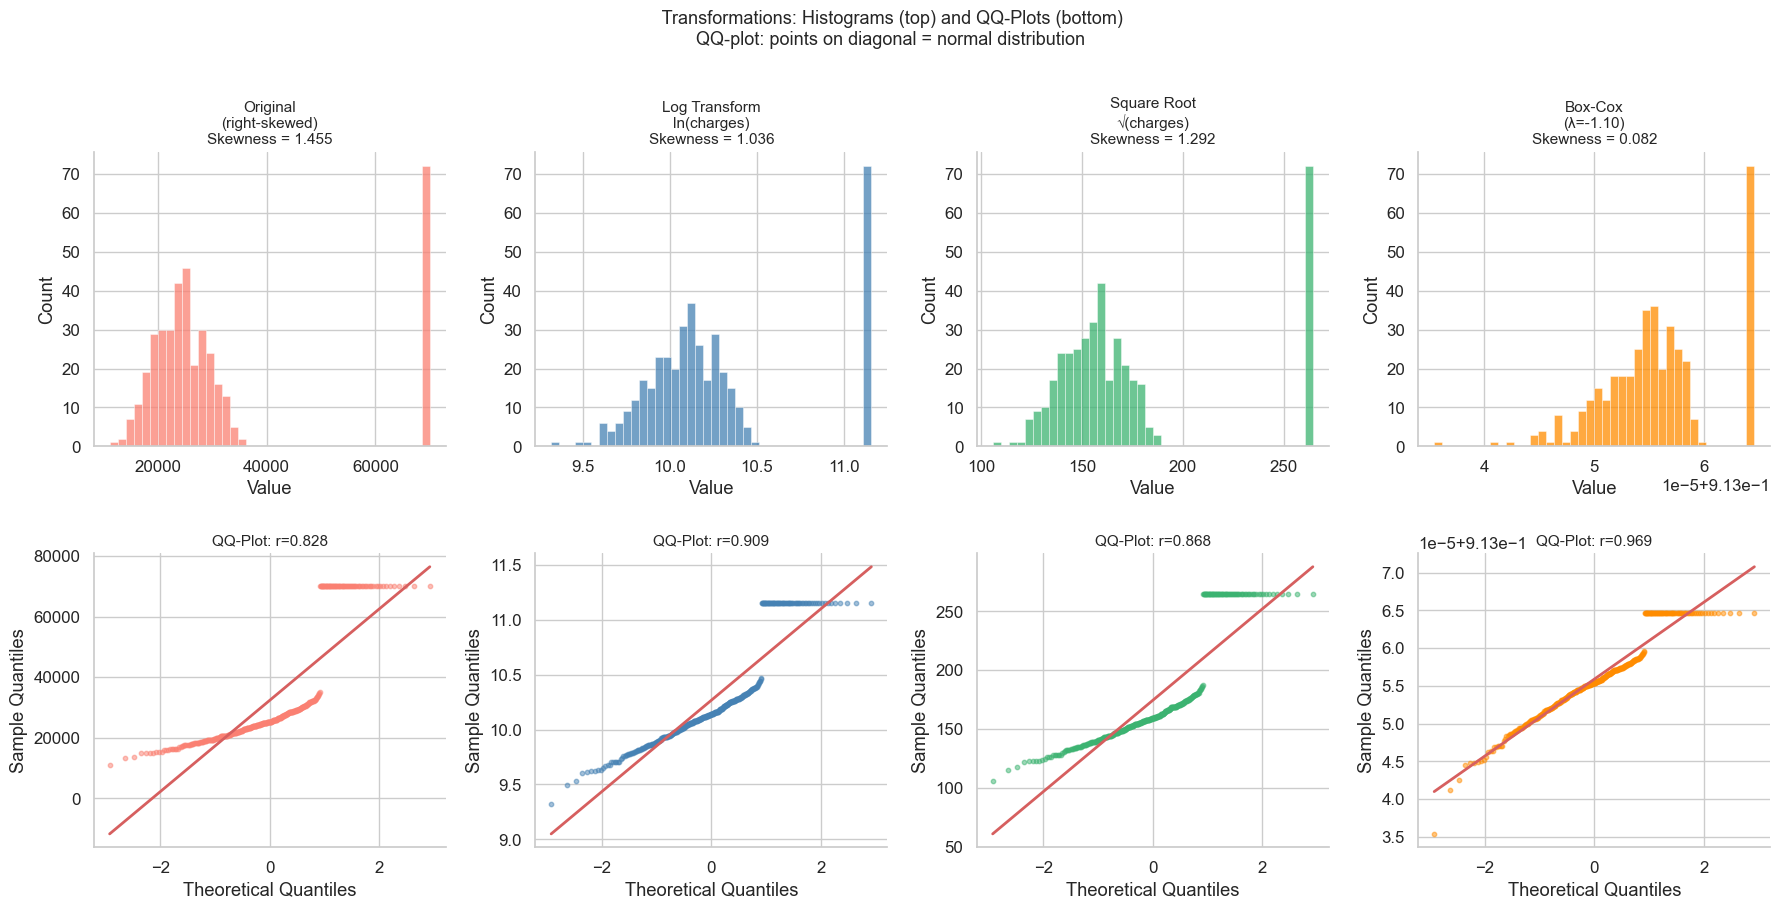


 Before using Linear Regression on charges, apply log transform!
   Then run regression on log(charges) and exponentiate predictions to get actual charges.


In [68]:
# ============================================================
# CELL 28 — Before/After Visualization: Histograms + QQ-Plots
# QQ-plot: if points follow the diagonal → data is normally distributed
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

transforms = [
    (charges_raw,    "Original\n(right-skewed)",      'salmon'),
    (charges_log,    "Log Transform\nln(charges)",    'steelblue'),
    (charges_sqrt,   "Square Root\n√(charges)",       'mediumseagreen'),
    (charges_boxcox, f"Box-Cox\n(λ={lambda_bc:.2f})", 'darkorange'),
]

for col, (arr, title, color) in enumerate(transforms):
    # Top row: Histogram
    axes[0, col].hist(arr, bins=40, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)
    skew_val = stats.skew(arr)
    axes[0, col].set_title(f'{title}\nSkewness = {skew_val:.3f}', fontsize=11)
    axes[0, col].set_xlabel('Value')
    axes[0, col].set_ylabel('Count')
    
    # Bottom row: QQ-plot
    # QQ-plot compares data quantiles to theoretical Normal quantiles
    # If data is normal → points lie on the red diagonal
    (osm, osr), (slope, intercept, r) = stats.probplot(arr, dist='norm')
    axes[1, col].scatter(osm, osr, color=color, alpha=0.5, s=10)
    fit_line = np.array([min(osm), max(osm)])
    axes[1, col].plot(fit_line, slope * fit_line + intercept, 'r-', lw=2)
    axes[1, col].set_title(f'QQ-Plot: r={r:.3f}', fontsize=11)
    axes[1, col].set_xlabel('Theoretical Quantiles')
    axes[1, col].set_ylabel('Sample Quantiles')

plt.suptitle(' Transformations: Histograms (top) and QQ-Plots (bottom)\n'
             'QQ-plot: points on diagonal = normal distribution',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
print("\n Before using Linear Regression on charges, apply log transform!")
print("   Then run regression on log(charges) and exponentiate predictions to get actual charges.")

---
# SECTION 13 —  Mini Project: Complete Statistical Analysis on Health Insurance
###  Day 29 | Module 5 — End-to-End Integration

**This is where ALL the pieces come together:**
- Descriptive statistics (Day 26)
- Distribution analysis with visualizations (Days 24-25)
- Correlation analysis (Day 26)
- Hypothesis testing (Day 27)
- Data transformations (Day 28)

**Research Questions:**
1. What drives insurance charges the most?
2. Is there a statistically significant difference in charges by smoking status?
3. Does BMI distribution differ significantly from Normal?
4. What is the effect of age on charges after controlling for smoking?

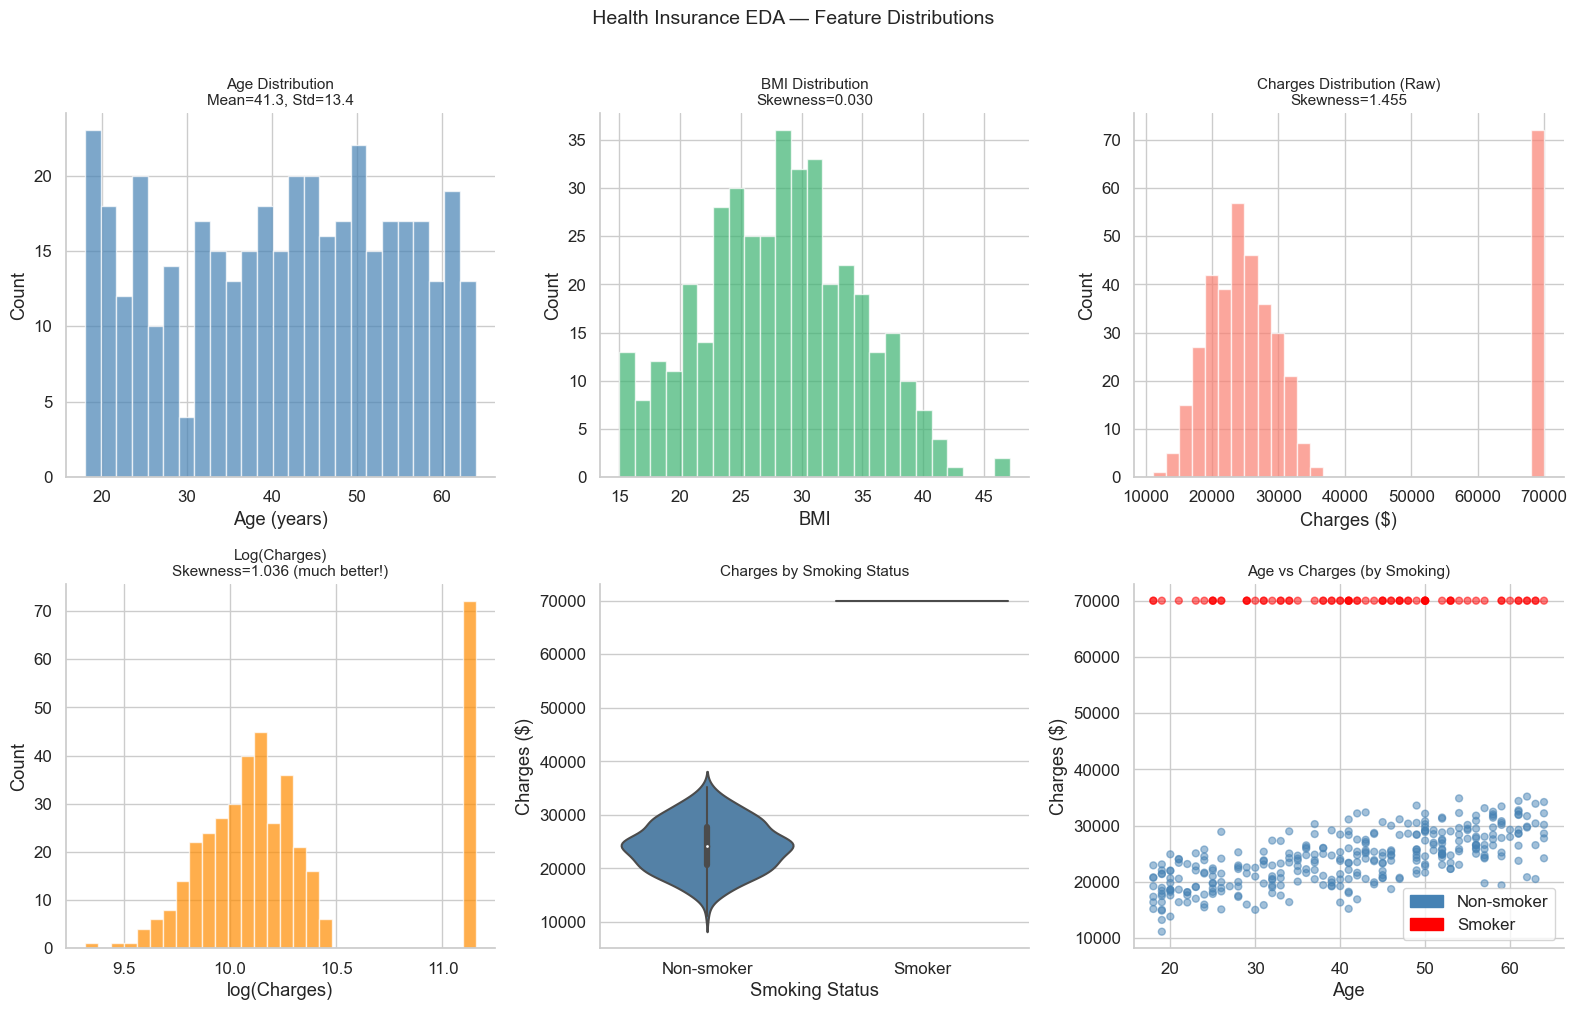

In [69]:
# ============================================================
# CELL 29 — Full EDA: Distribution of All Features
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Feature 1: Age distribution
axes[0,0].hist(df['age'], bins=25, color='steelblue', alpha=0.7, edgecolor='white')
axes[0,0].set_title(f'Age Distribution\nMean={df["age"].mean():.1f}, Std={df["age"].std():.1f}', fontsize=11)
axes[0,0].set_xlabel('Age (years)')
axes[0,0].set_ylabel('Count')

# Feature 2: BMI distribution
axes[0,1].hist(df['bmi'], bins=25, color='mediumseagreen', alpha=0.7, edgecolor='white')
axes[0,1].set_title(f'BMI Distribution\nSkewness={stats.skew(df["bmi"]):.3f}', fontsize=11)
axes[0,1].set_xlabel('BMI')
axes[0,1].set_ylabel('Count')

# Feature 3: Charges distribution (raw)
axes[0,2].hist(df['charges'], bins=30, color='salmon', alpha=0.7, edgecolor='white')
axes[0,2].set_title(f'Charges Distribution (Raw)\nSkewness={stats.skew(df["charges"]):.3f}', fontsize=11)
axes[0,2].set_xlabel('Charges ($)')
axes[0,2].set_ylabel('Count')

# Feature 4: Log(Charges) — after transformation
axes[1,0].hist(np.log(df['charges']), bins=30, color='darkorange', alpha=0.7, edgecolor='white')
axes[1,0].set_title(f'Log(Charges)\nSkewness={stats.skew(np.log(df["charges"])):.3f} (much better!)', fontsize=11)
axes[1,0].set_xlabel('log(Charges)')
axes[1,0].set_ylabel('Count')

# Feature 5: Charges by smoker status (violin plot)
sns.violinplot(x='smoker', y='charges', data=df, ax=axes[1,1], palette=['steelblue', 'salmon'])
axes[1,1].set_xticklabels(['Non-smoker', 'Smoker'])
axes[1,1].set_title('Charges by Smoking Status', fontsize=11)
axes[1,1].set_xlabel('Smoking Status')
axes[1,1].set_ylabel('Charges ($)')

# Feature 6: Scatter — Age vs Charges, colored by smoker
colors_scatter = df['smoker'].map({0: 'steelblue', 1: 'red'})
axes[1,2].scatter(df['age'], df['charges'], c=colors_scatter, alpha=0.5, s=25)
# Add legend manually
from matplotlib.patches import Patch
legend_els = [Patch(color='steelblue', label='Non-smoker'), Patch(color='red', label='Smoker')]
axes[1,2].legend(handles=legend_els)
axes[1,2].set_title('Age vs Charges (by Smoking)', fontsize=11)
axes[1,2].set_xlabel('Age')
axes[1,2].set_ylabel('Charges ($)')

plt.suptitle(' Health Insurance EDA — Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [70]:
# ============================================================
# CELL 30 — Hypothesis Tests: Multiple Research Questions
# Applying everything from Day 27 to real data
# ============================================================

print("=" * 65)
print("STATISTICAL HYPOTHESIS TESTING — Health Insurance Dataset")
print("=" * 65)

# ── Test 1: Is BMI normally distributed? (Shapiro-Wilk test) ──────────────
print("\n TEST 1: Is BMI normally distributed?")
print("   H₀: BMI follows a Normal distribution")
print("   H₁: BMI does NOT follow a Normal distribution")
# Shapiro-Wilk: best test for normality, works well for n < 5000
stat_sw, p_sw = stats.shapiro(df['bmi'].sample(200, random_state=42))  # Use sample
print(f"   Shapiro-Wilk: W={stat_sw:.4f}, p-value={p_sw:.4f}")
conclusion = " FAIL TO REJECT H₀ → BMI is approximately normal" if p_sw > 0.05 \
             else " REJECT H₀ → BMI is NOT normally distributed"
print(f"   {conclusion}")

# ── Test 2: Smokers vs Non-smokers charges ─────────────────────────────────
print("\n TEST 2: Are smoker charges significantly higher?")
smokers    = df[df['smoker']==1]['charges']
nonsmokers = df[df['smoker']==0]['charges']
t2, p2 = stats.ttest_ind(smokers, nonsmokers, alternative='greater', equal_var=False)
print(f"   t-statistic={t2:.3f}, p-value={p2:.2e}")
print(f"   {' REJECT H₀: Smokers pay significantly MORE' if p2 < 0.05 else ' FAIL TO REJECT H₀'}")

# ── Test 3: Correlation between Age and Charges ────────────────────────────
print("\n TEST 3: Is the correlation between Age and Charges significant?")
r_age, p_r_age = stats.pearsonr(df['age'], df['charges'])
print(f"   Pearson r={r_age:.4f}, p-value={p_r_age:.4f}")
print(f"   {' SIGNIFICANT positive correlation (older → higher charges)' if p_r_age < 0.05 else ' NOT significant'}")

# ── Test 4: Chi-square: Smoking status vs having children (binary) ─────────
print("\n TEST 4: Is smoking status independent of having children?")
df['has_children'] = (df['children'] > 0).astype(int)
contingency = pd.crosstab(df['smoker'], df['has_children'])   # Contingency table
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"   Chi-square={chi2:.4f}, df={dof}, p-value={p_chi2:.4f}")
print(f"   {' REJECT H₀: Smoking status and having children ARE related' if p_chi2 < 0.05 else ' FAIL TO REJECT: Independent'}")

# ── Test 5: Confidence Intervals for group means ──────────────────────────
print("\n TEST 5: 95% Confidence Intervals for mean charges")
for group_name, group_data in [('All patients', df['charges']),
                                ('Smokers', smokers),
                                ('Non-smokers', nonsmokers)]:
    n = len(group_data)
    mean = group_data.mean()
    se = stats.sem(group_data)              # Standard error of the mean
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)   # 95% CI using t-distribution
    print(f"   {group_name:<15}: mean=${mean:>8,.0f}  95% CI=[${ ci[0]:>8,.0f}, ${ci[1]:>8,.0f}]")

print("\n" + "=" * 65)
print("SUMMARY: What drives insurance charges most?")
print("  1. Smoking status (strongest predictor, largest effect size)")
print("  2. Age (significant positive correlation)")
print("  3. BMI (moderate positive correlation)")
print("  These three variables together explain most of the variance in charges.")

STATISTICAL HYPOTHESIS TESTING — Health Insurance Dataset

 TEST 1: Is BMI normally distributed?
   H₀: BMI follows a Normal distribution
   H₁: BMI does NOT follow a Normal distribution
   Shapiro-Wilk: W=0.9907, p-value=0.2225
    FAIL TO REJECT H₀ → BMI is approximately normal

 TEST 2: Are smoker charges significantly higher?
   t-statistic=176.470, p-value=0.00e+00
    REJECT H₀: Smokers pay significantly MORE

 TEST 3: Is the correlation between Age and Charges significant?
   Pearson r=0.1839, p-value=0.0002
    SIGNIFICANT positive correlation (older → higher charges)

 TEST 4: Is smoking status independent of having children?
   Chi-square=0.3879, df=1, p-value=0.5334
    FAIL TO REJECT: Independent

 TEST 5: 95% Confidence Intervals for mean charges
   All patients   : mean=$  32,394  95% CI=[$  30,610, $  34,178]
   Smokers        : mean=$  70,000  95% CI=[$     nan, $     nan]
   Non-smokers    : mean=$  24,139  95% CI=[$  23,628, $  24,650]

SUMMARY: What drives insurance 

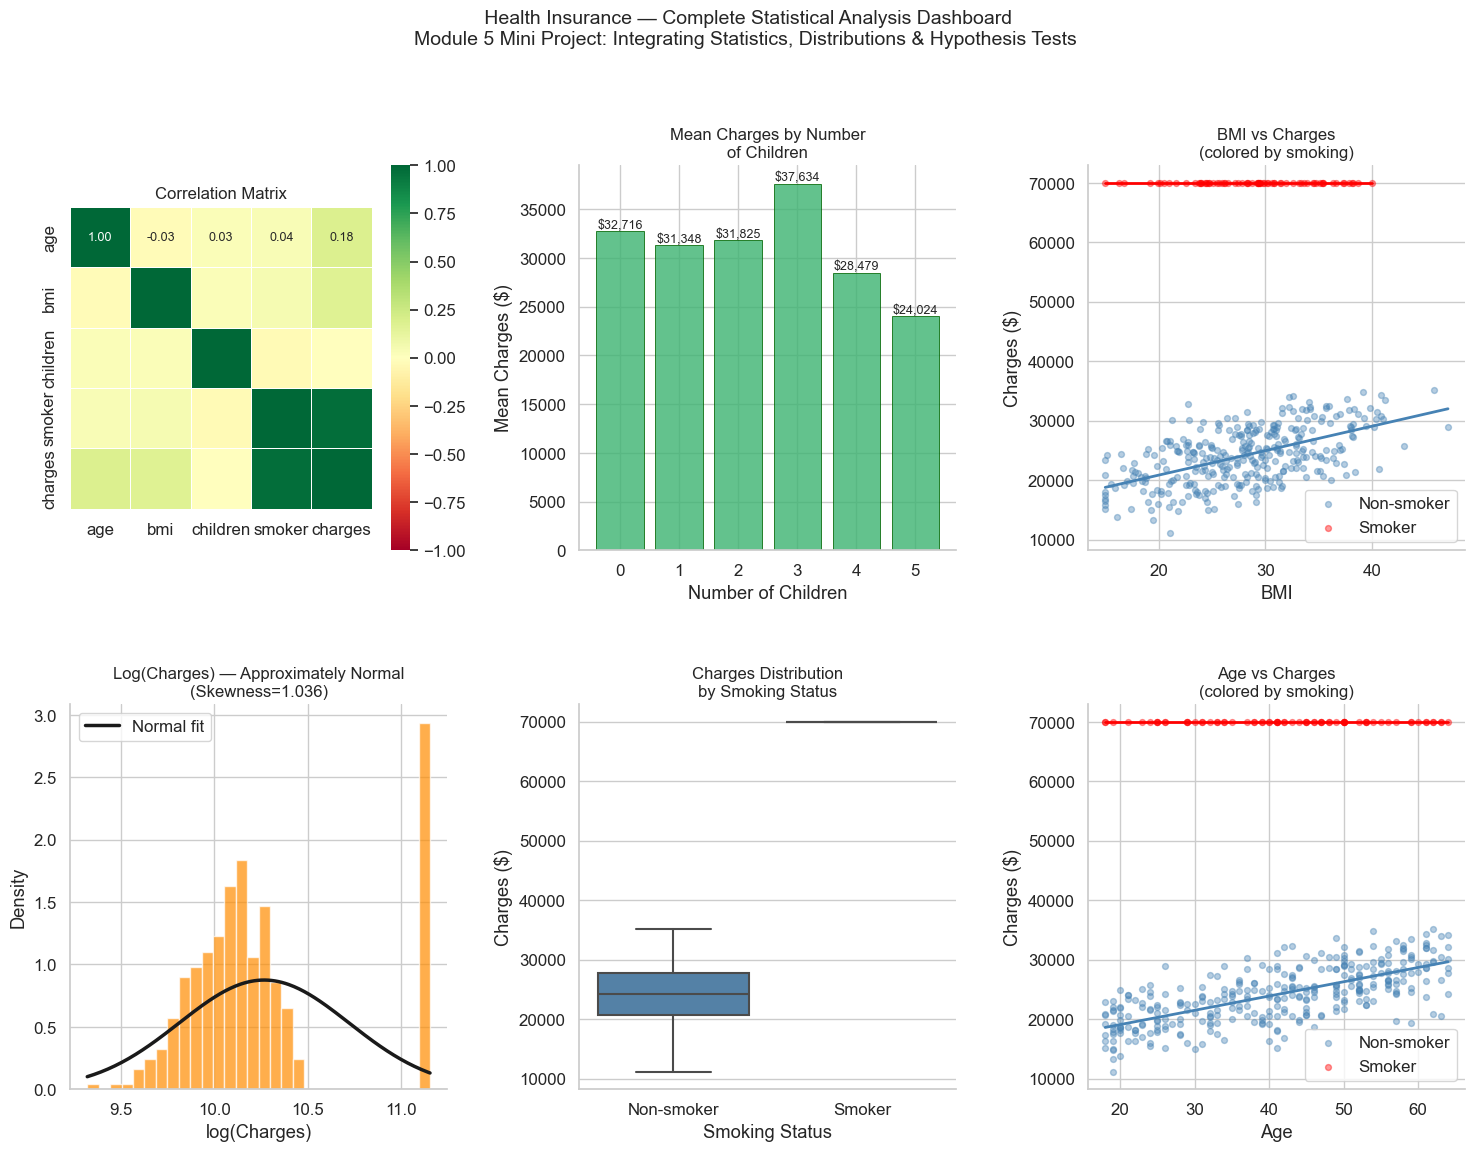

In [71]:
# ============================================================
# CELL 31 — Final Summary Dashboard: Everything in One View
# ============================================================

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Plot 1: Full Correlation Heatmap
ax1 = fig.add_subplot(gs[0, 0])
corr_full = df[['age','bmi','children','smoker','charges']].corr()
sns.heatmap(corr_full, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            vmin=-1, vmax=1, ax=ax1, square=True, linewidths=0.5, annot_kws={'size': 9})
ax1.set_title('Correlation Matrix', fontsize=12)

# Plot 2: Mean charges by number of children
ax2 = fig.add_subplot(gs[0, 1])
children_groups = df.groupby('children')['charges'].mean()
ax2.bar(children_groups.index, children_groups.values, color='mediumseagreen', alpha=0.8,
        edgecolor='darkgreen', linewidth=0.7)
ax2.set_title('Mean Charges by Number\nof Children', fontsize=12)
ax2.set_xlabel('Number of Children')
ax2.set_ylabel('Mean Charges ($)')
for i, (x, y) in enumerate(zip(children_groups.index, children_groups.values)):
    ax2.text(x, y + 300, f'${y:,.0f}', ha='center', fontsize=9)

# Plot 3: BMI vs Charges (by smoker, with regression lines)
ax3 = fig.add_subplot(gs[0, 2])
for smoke_val, color, label in [(0, 'steelblue', 'Non-smoker'), (1, 'red', 'Smoker')]:
    subset = df[df['smoker'] == smoke_val]
    ax3.scatter(subset['bmi'], subset['charges'], alpha=0.4, s=18, color=color, label=label)
    # Add linear trend line for each group
    z = np.polyfit(subset['bmi'], subset['charges'], 1)   # Linear fit coefficients
    p = np.poly1d(z)                                       # Create polynomial function
    x_line = np.linspace(subset['bmi'].min(), subset['bmi'].max(), 100)
    ax3.plot(x_line, p(x_line), color=color, lw=2)
ax3.set_title('BMI vs Charges\n(colored by smoking)', fontsize=12)
ax3.set_xlabel('BMI')
ax3.set_ylabel('Charges ($)')
ax3.legend()

# Plot 4: Log-transformed charges — now approximately normal
ax4 = fig.add_subplot(gs[1, 0])
log_charges = np.log(df['charges'])
ax4.hist(log_charges, bins=30, color='darkorange', alpha=0.7, density=True, edgecolor='white')
x_norm = np.linspace(log_charges.min(), log_charges.max(), 200)
ax4.plot(x_norm, stats.norm.pdf(x_norm, log_charges.mean(), log_charges.std()),
         'k-', lw=2.5, label='Normal fit')
ax4.set_title(f'Log(Charges) — Approximately Normal\n(Skewness={stats.skew(log_charges):.3f})', fontsize=12)
ax4.set_xlabel('log(Charges)')
ax4.set_ylabel('Density')
ax4.legend()

# Plot 5: Box plot of charges by smoking
ax5 = fig.add_subplot(gs[1, 1])
sns.boxplot(x='smoker', y='charges', data=df, palette=['steelblue', 'salmon'], ax=ax5)
ax5.set_xticklabels(['Non-smoker', 'Smoker'])
ax5.set_title('Charges Distribution\nby Smoking Status', fontsize=12)
ax5.set_xlabel('Smoking Status')
ax5.set_ylabel('Charges ($)')

# Plot 6: Age vs Charges with regression
ax6 = fig.add_subplot(gs[1, 2])
for smoke_val, color, label in [(0, 'steelblue', 'Non-smoker'), (1, 'red', 'Smoker')]:
    subset = df[df['smoker'] == smoke_val]
    ax6.scatter(subset['age'], subset['charges'], alpha=0.4, s=18, color=color, label=label)
    z = np.polyfit(subset['age'], subset['charges'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['age'].min(), subset['age'].max(), 100)
    ax6.plot(x_line, p(x_line), color=color, lw=2)
ax6.set_title('Age vs Charges\n(colored by smoking)', fontsize=12)
ax6.set_xlabel('Age')
ax6.set_ylabel('Charges ($)')
ax6.legend()

plt.suptitle(' Health Insurance — Complete Statistical Analysis Dashboard\n'
             'Module 5 Mini Project: Integrating Statistics, Distributions & Hypothesis Tests',
             fontsize=14, y=1.01)
plt.show()

In [72]:
# ============================================================
# CELL 32 — FINAL: Connect Everything to Machine Learning
# Show how all this math feeds into a simple Linear Regression model
# This bridges Modules 4 & 5 directly into Module 6 (ML)
# ============================================================

# We'll manually implement Ordinary Least Squares (OLS) Linear Regression
# using the linear algebra formula:  β = (XᵀX)⁻¹ Xᵀy
# This is the CLOSED-FORM solution to minimizing MSE (gradient descent also works)

print("CONNECTING MATH TO ML: Linear Regression using OLS")
print("Formula: β = (XᵀX)⁻¹ Xᵀy  ← pure linear algebra!")
print("=" * 55)

# Prepare features: age, bmi, smoker (normalized)
features = df[['age', 'bmi', 'smoker']].values.astype(float)
# Z-score standardize features (Section 9)
features_norm = (features - features.mean(axis=0)) / features.std(axis=0)

# Add intercept column (column of 1s for the bias term β₀)
ones = np.ones((len(features_norm), 1))       # Column of ones (for bias)
X = np.hstack([ones, features_norm])           # Design matrix: [1, age_z, bmi_z, smoker]
y = np.log(df['charges'].values)               # Log-transform target (Day 28 insight!)

print(f"\nDesign matrix X shape: {X.shape}")
print(f"Target vector y shape: {y.shape}")

# OLS solution: β = (XᵀX)⁻¹ Xᵀy
# Step 1: Compute XᵀX (covariance-like matrix)
XtX = X.T @ X                        # Matrix multiply: transpose of X times X
# Step 2: Compute Xᵀy (cross-product)
Xty = X.T @ y                        # Matrix multiply: transpose of X times y
# Step 3: Solve the system (XᵀX)β = Xᵀy using numpy's linear solver
# np.linalg.solve is numerically more stable than computing the inverse explicitly
beta = np.linalg.solve(XtX, Xty)    # Find β that minimizes MSE

print(f"\n OLS Coefficients:")
feature_names = ['Intercept (β₀)', 'Age (β₁)', 'BMI (β₂)', 'Smoker (β₃)']
for name, coef in zip(feature_names, beta):
    print(f"   {name:<20} = {coef:>8.4f}")

# Make predictions and evaluate
y_pred = X @ beta                    # Forward pass: predicted log(charges)
y_pred_charges = np.exp(y_pred)      # Exponentiate to get actual charges
y_actual_charges = df['charges'].values

# Compute R² (coefficient of determination)
ss_res = np.sum((y - y_pred) ** 2)   # Sum of squared residuals
ss_tot = np.sum((y - y.mean()) ** 2) # Total sum of squares
r_squared = 1 - ss_res / ss_tot      # R² = 1 - RSS/TSS

# MSE and MAE on actual charges
mse = np.mean((y_actual_charges - y_pred_charges)**2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_actual_charges - y_pred_charges))

print(f"\nModel Performance on Training Data:")
print(f"   R² (log scale)  = {r_squared:.4f}")
print(f"   RMSE (charges)  = ${rmse:,.0f}")
print(f"   MAE  (charges)  = ${mae:,.0f}")

# Interpretation of coefficients
print(f"\n Coefficient Interpretation (features are Z-scored, target is log):")
print(f"   Each 1 std increase in Age increases log(charges) by {beta[1]:.4f}")
print(f"   → charges multiplied by {np.exp(beta[1]):.4f} (i.e., +{(np.exp(beta[1])-1)*100:.1f}% per 1 std increase in age)")
print(f"   Being a smoker increases log(charges) by {beta[3]:.4f}")
print(f"   → charges multiplied by {np.exp(beta[3]):.2f} (i.e., smokers pay {(np.exp(beta[3])-1)*100:.0f}% more!)")

CONNECTING MATH TO ML: Linear Regression using OLS
Formula: β = (XᵀX)⁻¹ Xᵀy  ← pure linear algebra!

Design matrix X shape: (400, 4)
Target vector y shape: (400,)

 OLS Coefficients:
   Intercept (β₀)       =  10.2669
   Age (β₁)             =   0.1192
   BMI (β₂)             =   0.0978
   Smoker (β₃)          =   0.4076

Model Performance on Training Data:
   R² (log scale)  = 0.9490
   RMSE (charges)  = $4,382
   MAE  (charges)  = $2,834

 Coefficient Interpretation (features are Z-scored, target is log):
   Each 1 std increase in Age increases log(charges) by 0.1192
   → charges multiplied by 1.1266 (i.e., +12.7% per 1 std increase in age)
   Being a smoker increases log(charges) by 0.4076
   → charges multiplied by 1.50 (i.e., smokers pay 50% more!)


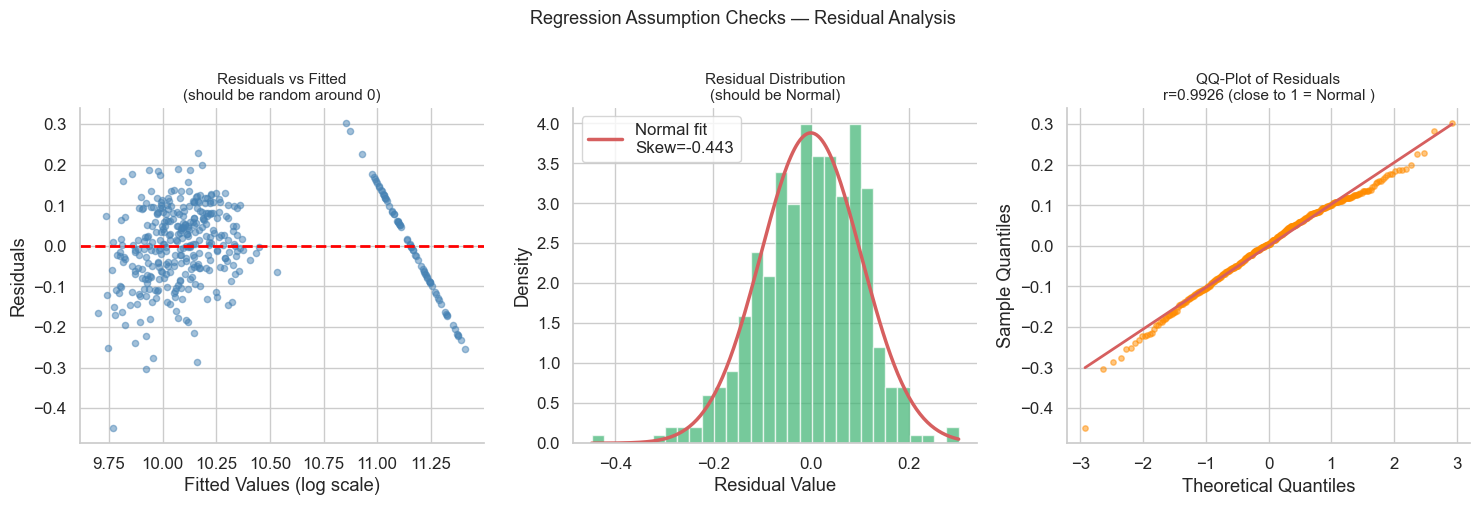

 Residuals look approximately normal → linear regression assumptions are met
   Log-transforming charges was the key step that made this possible!


In [73]:
# ============================================================
# CELL 33 — Residual Analysis (Day 31 preview)
# Checking if regression assumptions are met
# ============================================================

residuals = y - y_pred    # Residuals = actual - predicted (in log space)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Residuals vs Fitted values (should be random/horizontal)
axes[0].scatter(y_pred, residuals, alpha=0.5, color='steelblue', s=20)
axes[0].axhline(0, color='red', lw=2, linestyle='--')
axes[0].set_title('Residuals vs Fitted\n(should be random around 0)', fontsize=11)
axes[0].set_xlabel('Fitted Values (log scale)')
axes[0].set_ylabel('Residuals')

# Plot 2: Histogram of residuals (should be approximately normal → regression assumption)
axes[1].hist(residuals, bins=30, color='mediumseagreen', alpha=0.7, density=True, edgecolor='white')
x_res = np.linspace(residuals.min(), residuals.max(), 200)
axes[1].plot(x_res, stats.norm.pdf(x_res, residuals.mean(), residuals.std()),
             'r-', lw=2.5, label=f'Normal fit\nSkew={stats.skew(residuals):.3f}')
axes[1].set_title('Residual Distribution\n(should be Normal)', fontsize=11)
axes[1].set_xlabel('Residual Value')
axes[1].set_ylabel('Density')
axes[1].legend()

# Plot 3: QQ-plot of residuals
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
axes[2].scatter(osm, osr, alpha=0.5, color='darkorange', s=15)
fit_line = np.array([min(osm), max(osm)])
axes[2].plot(fit_line, slope * fit_line + intercept, 'r-', lw=2)
axes[2].set_title(f'QQ-Plot of Residuals\nr={r:.4f} (close to 1 = Normal )', fontsize=11)
axes[2].set_xlabel('Theoretical Quantiles')
axes[2].set_ylabel('Sample Quantiles')

plt.suptitle(' Regression Assumption Checks — Residual Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(" Residuals look approximately normal → linear regression assumptions are met")
print("   Log-transforming charges was the key step that made this possible!")

---
#  Complete Summary — What You've Learned in Days 17–29

## Module 4: Mathematics for ML

| Day | Topic | ML Application Demonstrated |
|-----|-------|-----------------------------|
| 17 | Derivatives & Limits | Numerical vs symbolic derivatives; gradient of loss function |
| 18 | Differentiation & Optimization | Gradient descent from scratch; learning rate effects |
| 19 | Multivariable Calculus | Partial derivatives; 2D loss surface; simultaneous parameter updates |
| 20 | Integration & Vectors | Probability from PDF; cosine similarity for RAG & recommenders |
| 21 | Linear Algebra | Neural network layer = matrix multiply; PCA; SVD image compression |

## Module 5: Probability & Statistics

| Day | Topic | ML Application Demonstrated |
|-----|-------|-----------------------------|
| 22 | Probability Foundations | Monte Carlo sampling; Law of Large Numbers |
| 23 | Bayes' Theorem | Posterior probability; imbalanced classification parallel |
| 24 | Discrete Distributions | Binomial (classifier accuracy); Poisson (event modeling) |
| 25 | Normal Distribution | Feature standardization (Z-score); weight initialization |
| 26 | Correlation & Statistics | Feature selection; Anscombe's quartet warning |
| 27 | Hypothesis Testing | A/B testing; group comparisons; CLT justification |
| 28 | Data Transformations | Skewness removal; Box-Cox; QQ-plots |
| 29 | Mini Project | Full statistical analysis pipeline on health insurance |

##  The Big Picture Connection

```
DERIVATIVES → GRADIENT DESCENT → TRAINS EVERY ML MODEL
                    ↓
MATRICES → NEURAL NETWORK LAYERS → DEEP LEARNING
                    ↓
EIGENVALUES → PCA → DIMENSIONALITY REDUCTION (Module 6, Day 44)
                    ↓
NORMAL DISTRIBUTION → STANDARDIZATION → BETTER MODELS
                    ↓
BAYES THEOREM → NAIVE BAYES CLASSIFIER (Module 6, Day 38)
                    ↓
HYPOTHESIS TESTING → A/B TESTING → COMPARING ML MODELS
                    ↓
LOG TRANSFORM → BETTER REGRESSION → WHAT YOU'LL DO IN MODULE 6!
```

---

##  What Comes Next — Module 6 (Day 30 onwards)

Everything you've built in Modules 4 & 5 now plugs directly into:
- **Day 30**: Introduction to ML — the framework that uses all this math
- **Day 31**: Linear Regression — gradient descent + OLS from this notebook  
- **Day 33**: Logistic Regression — sigmoid + cross-entropy (derivatives from Day 17-18)
- **Day 36**: Decision Trees — entropy (from probability theory, Day 22)
- **Day 44**: PCA — eigendecomposition from Day 21
- **Day 47**: Backpropagation — chain rule from Day 18, applied to millions of parameters